In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mc
import seaborn as sns
import os

In [25]:
sns.set_theme(style="whitegrid", context="paper", font_scale=1.3)
plt.rcParams['figure.dpi'] = 300         # Alta resolução
plt.rcParams['savefig.bbox'] = 'tight'   # Margens ajustadas
plt.rcParams['font.family'] = 'sans-serif'

In [26]:
def carregar_dados_epibuilder():
    """
    Lê os arquivos Excel específicos do ambiente do Colab.
    Extrai as abas 'Epitopes Detailed' e 'Protein Summary'.
    """

    arquivos_alvo = [
        "BORRELIA.xlsx",
        "CANDIDA.xlsx",
        "EBOLA.xlsx",
        "INFLUENZA.xlsx",
        "STAPHYLOCOCCUS.xlsx"
    ]

    dfs_detailed = []
    dfs_summary = []

    print("--- Iniciando Importação ---")

    for arquivo in arquivos_alvo:
        if os.path.exists(arquivo):
            print(f"Processando: {arquivo}...")
            nome_organismo = arquivo.replace(".xlsx", "").title() # Ex: BORRELIA -> Borrelia

            try:
                # Ler aba de Detalhes
                df_det = pd.read_excel(arquivo, sheet_name="Epitopes Detailed")
                df_det['Organism'] = nome_organismo
                dfs_detailed.append(df_det)

                # Ler aba de Resumo
                df_sum = pd.read_excel(arquivo, sheet_name="Protein Summary")
                df_sum['Organism'] = nome_organismo
                dfs_summary.append(df_sum)

            except ValueError as e:
                print(f"  ERRO: Abas não encontradas em {arquivo}. Verifique se as abas 'Epitopes Detailed' e 'Protein Summary' existem.")
        else:
            print(f"  AVISO: Arquivo {arquivo} não encontrado no ambiente. Pulei.")

    # Consolida tudo em dois grandes DataFrames
    if dfs_detailed and dfs_summary:
        final_detailed = pd.concat(dfs_detailed, ignore_index=True)
        final_summary = pd.concat(dfs_summary, ignore_index=True)
        print(f"\nSucesso! Carregados {len(final_detailed)} epítopos e {len(final_summary)} proteínas.")
        return final_detailed, final_summary
    else:
        print("\nNenhum dado foi carregado. Verifique os nomes dos arquivos.")
        return pd.DataFrame(), pd.DataFrame()

In [27]:
df_detailed, df_summary = carregar_dados_epibuilder()

#FILTRAGEM GLOBAL POR GLICOSILAÇÃO-N (N-Glyc == 'N')
if 'N-Glyc' in df_detailed.columns:
    # Filtra apenas os epítopos que NÃO são sítios de glicosilação (valor 'N')
    df_detailed_filtrado = df_detailed[df_detailed['N-Glyc'].astype(str).str.upper().isin(['N'])].copy()

    print(f"\n[FILTRO N-GLYC] Epítopos restantes: {len(df_detailed_filtrado)} (original: {len(df_detailed)})")

#Filtrar Proteínas (aba Summary): Mantém apenas proteínas com ZERO sítios (0)
if 'N-Glyc' in df_summary.columns:
    # Convertemos para string para evitar erros se o Excel leu como número ou texto
    df_summary = df_summary[df_summary['N-Glyc'].astype(str) == '0'].copy()
    print(f"[FILTRO SUMMARY] Proteínas com zero glicosilações (0): {len(df_summary)}")
else:
    print("\n[AVISO] Coluna 'N-Glyc' não encontrada na aba Summary.")

--- Iniciando Importação ---
Processando: BORRELIA.xlsx...
Processando: CANDIDA.xlsx...
Processando: EBOLA.xlsx...
Processando: INFLUENZA.xlsx...
Processando: STAPHYLOCOCCUS.xlsx...

Sucesso! Carregados 16267 epítopos e 8784 proteínas.

[FILTRO N-GLYC] Epítopos restantes: 12902 (original: 16267)
[FILTRO SUMMARY] Proteínas com zero glicosilações (0): 6723


Gráfico salvo: plot_A_prokaryotes.png


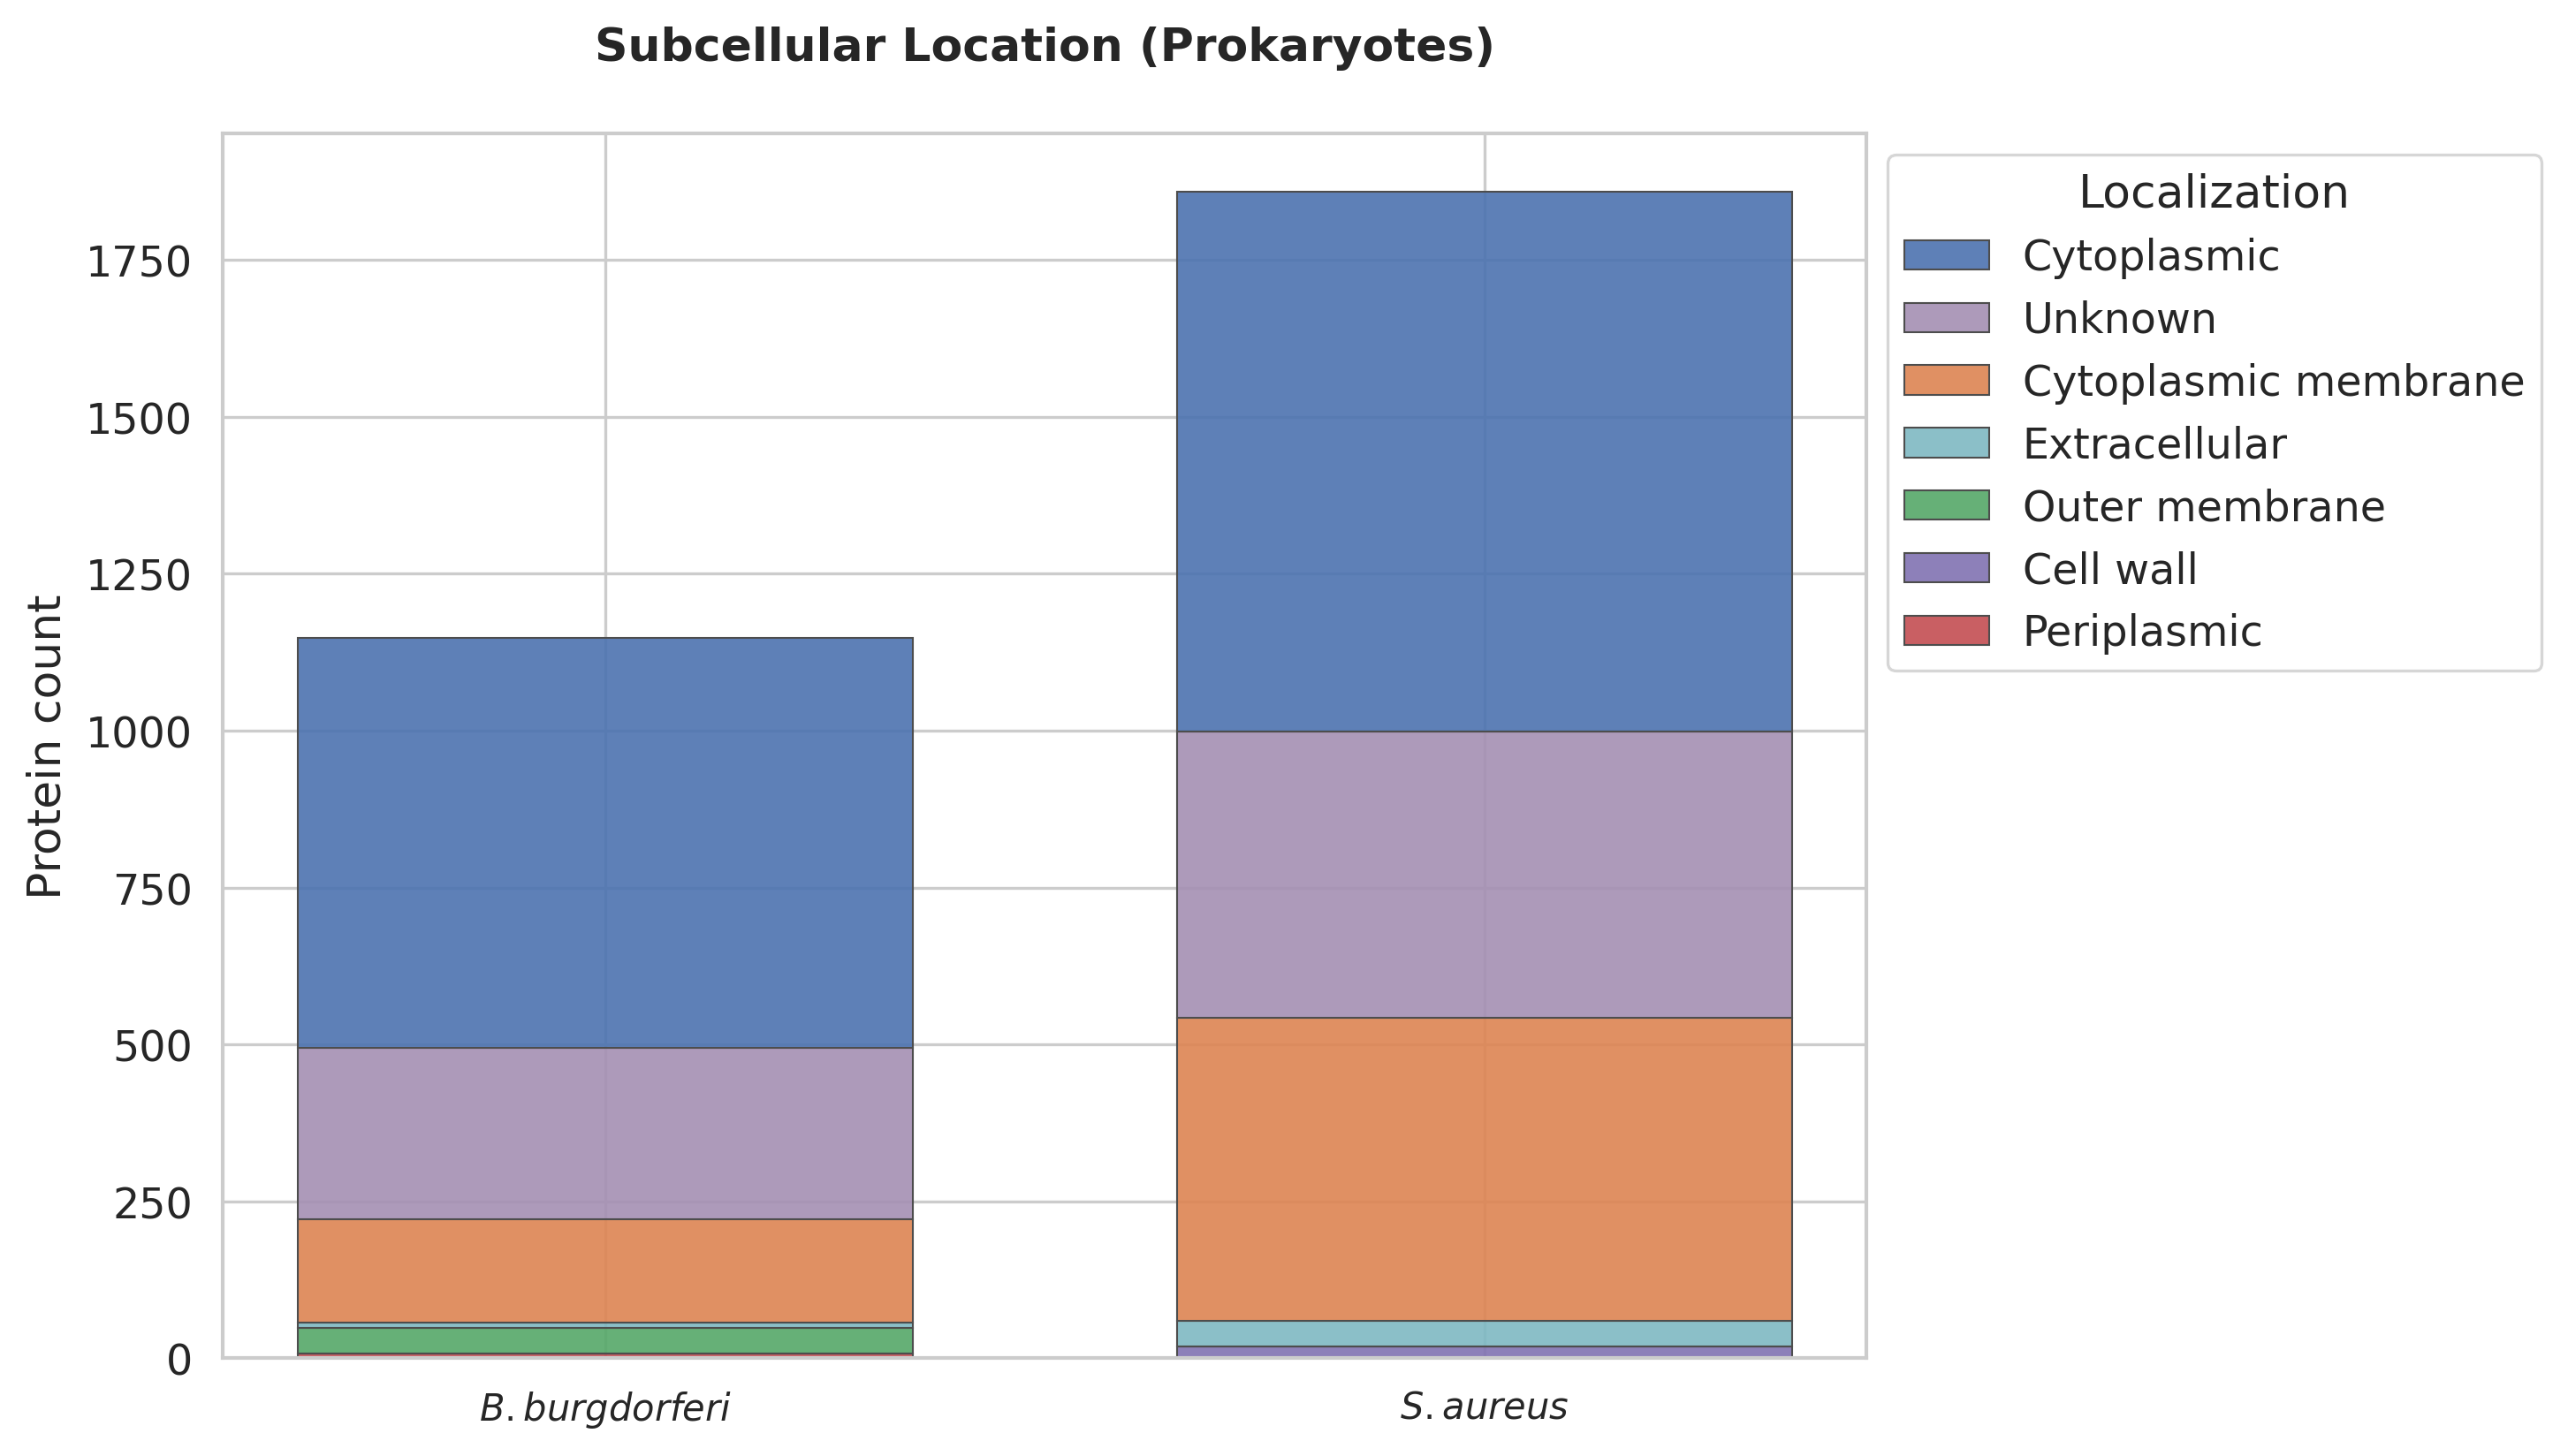

Gráfico salvo: plot_A_eukaryotes.png


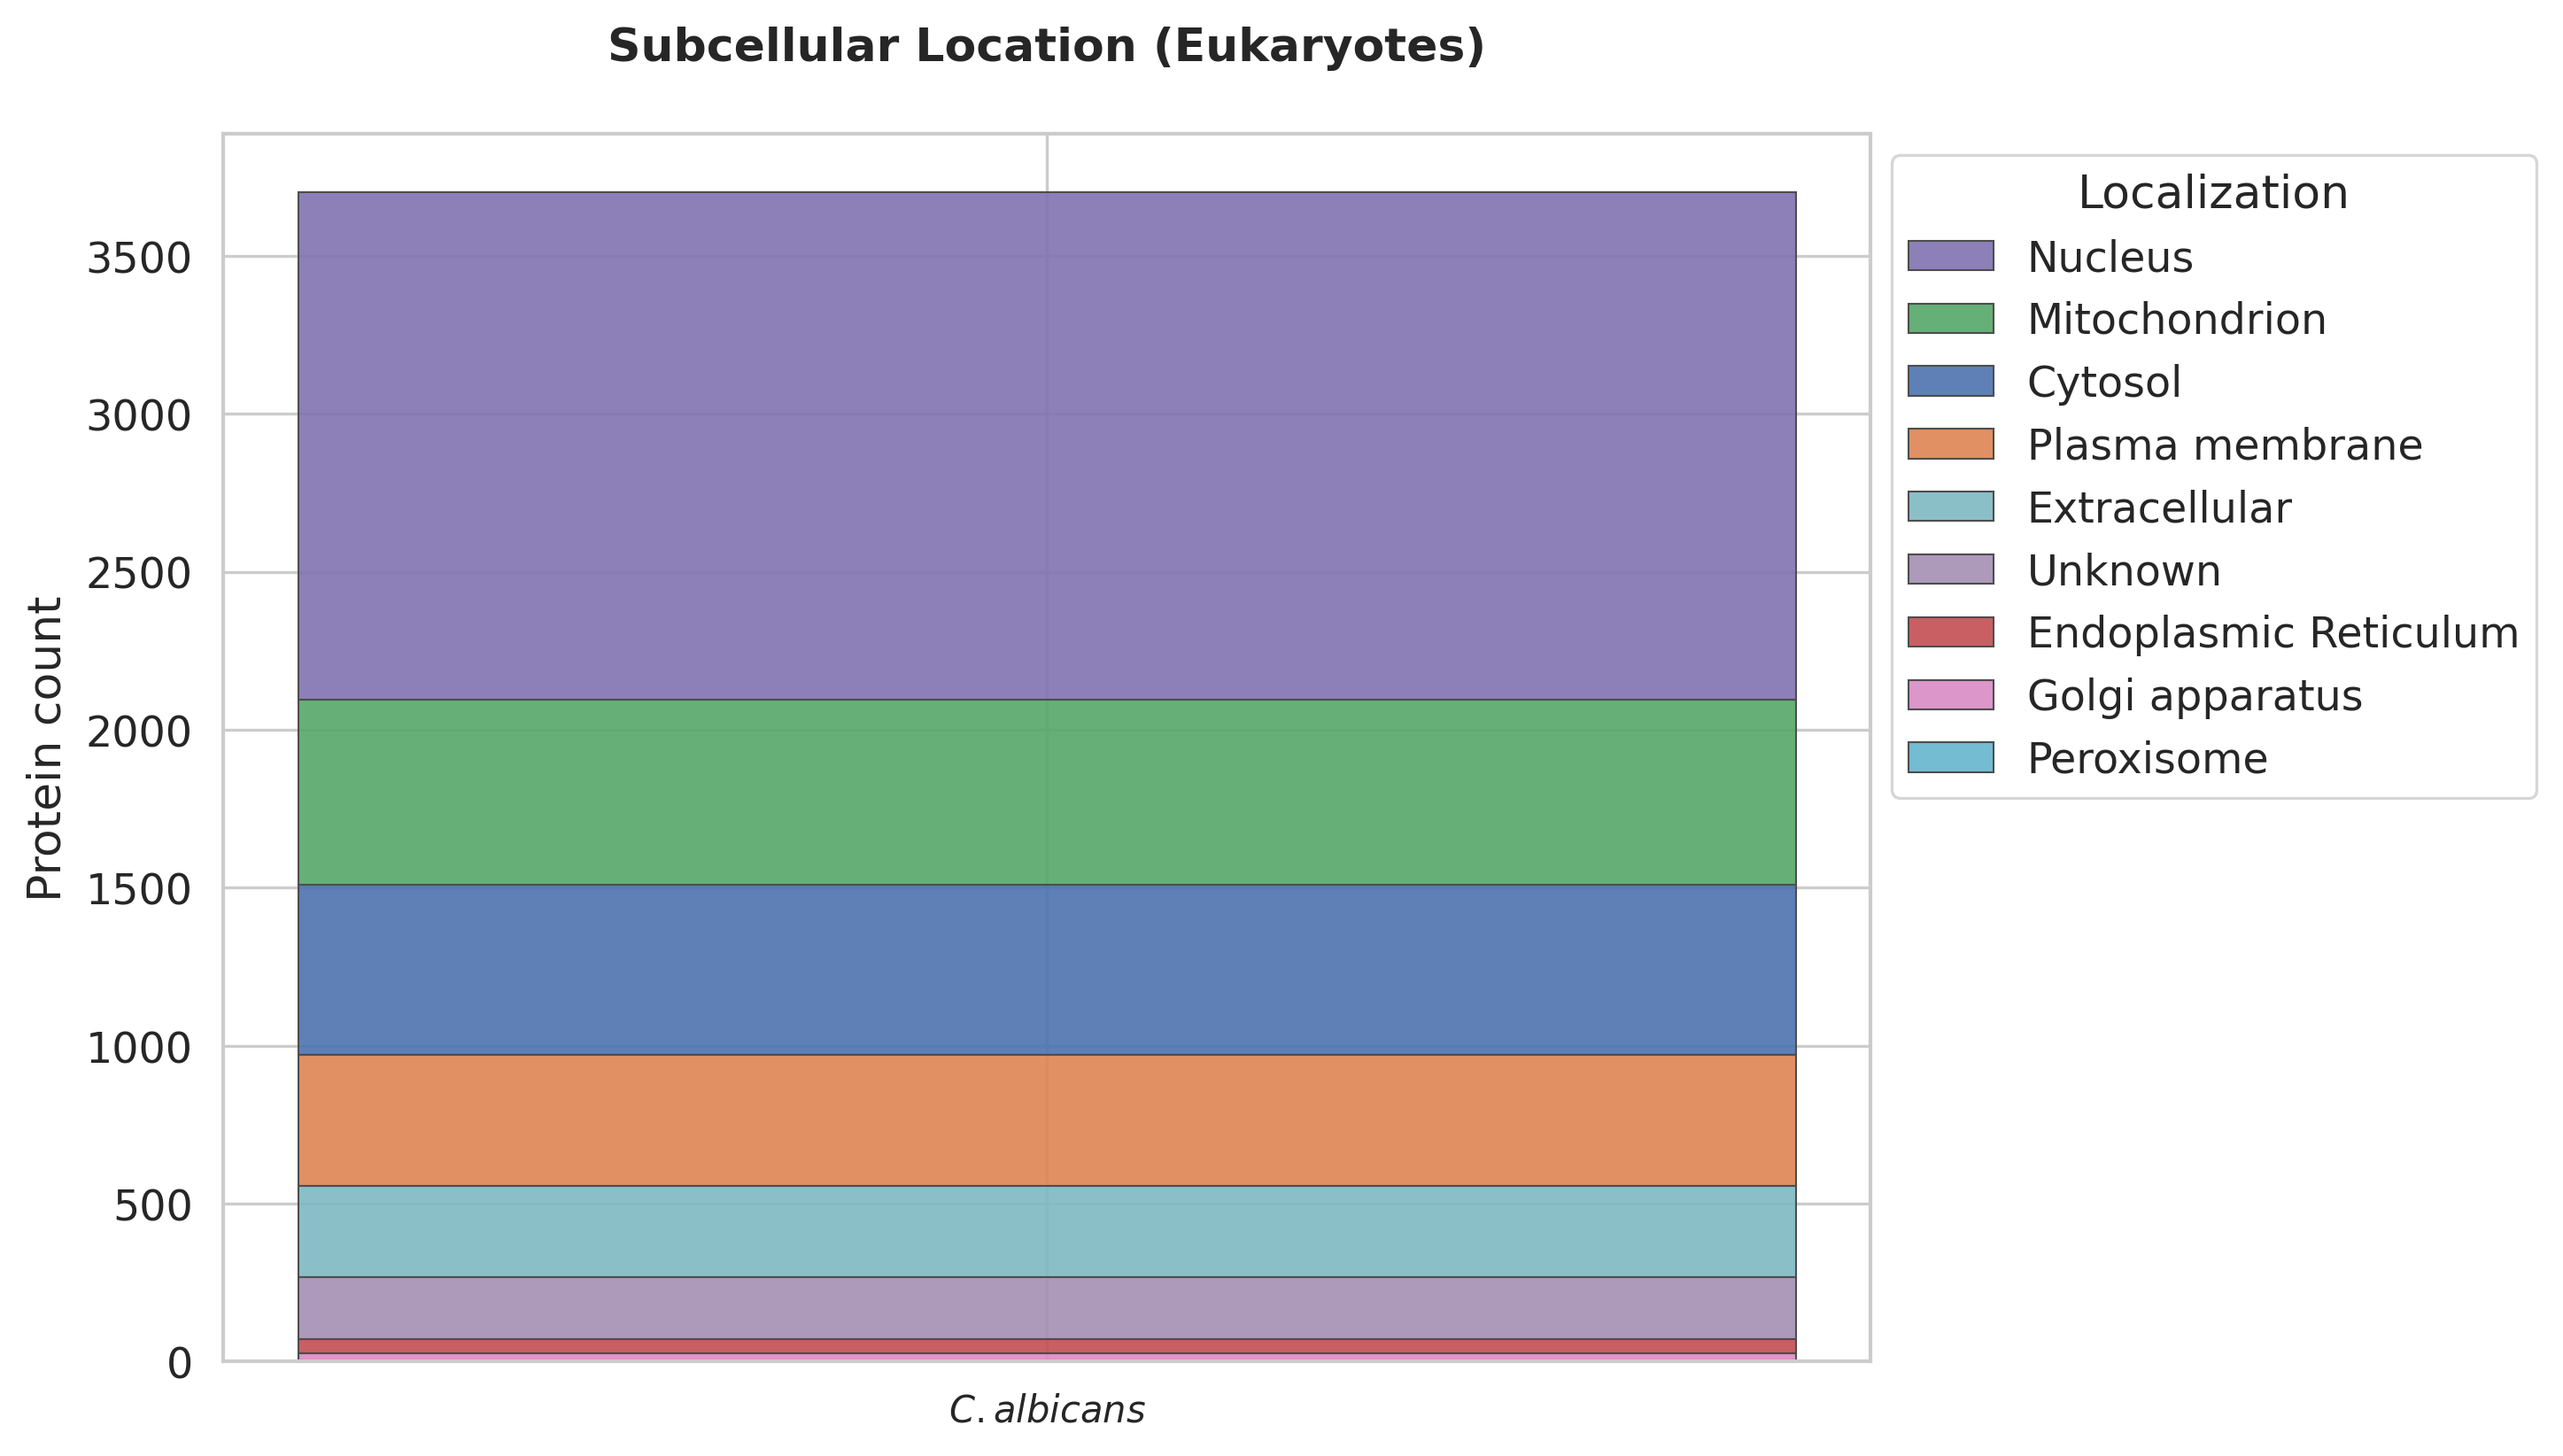

Gráfico salvo: plot_A_viruses.png


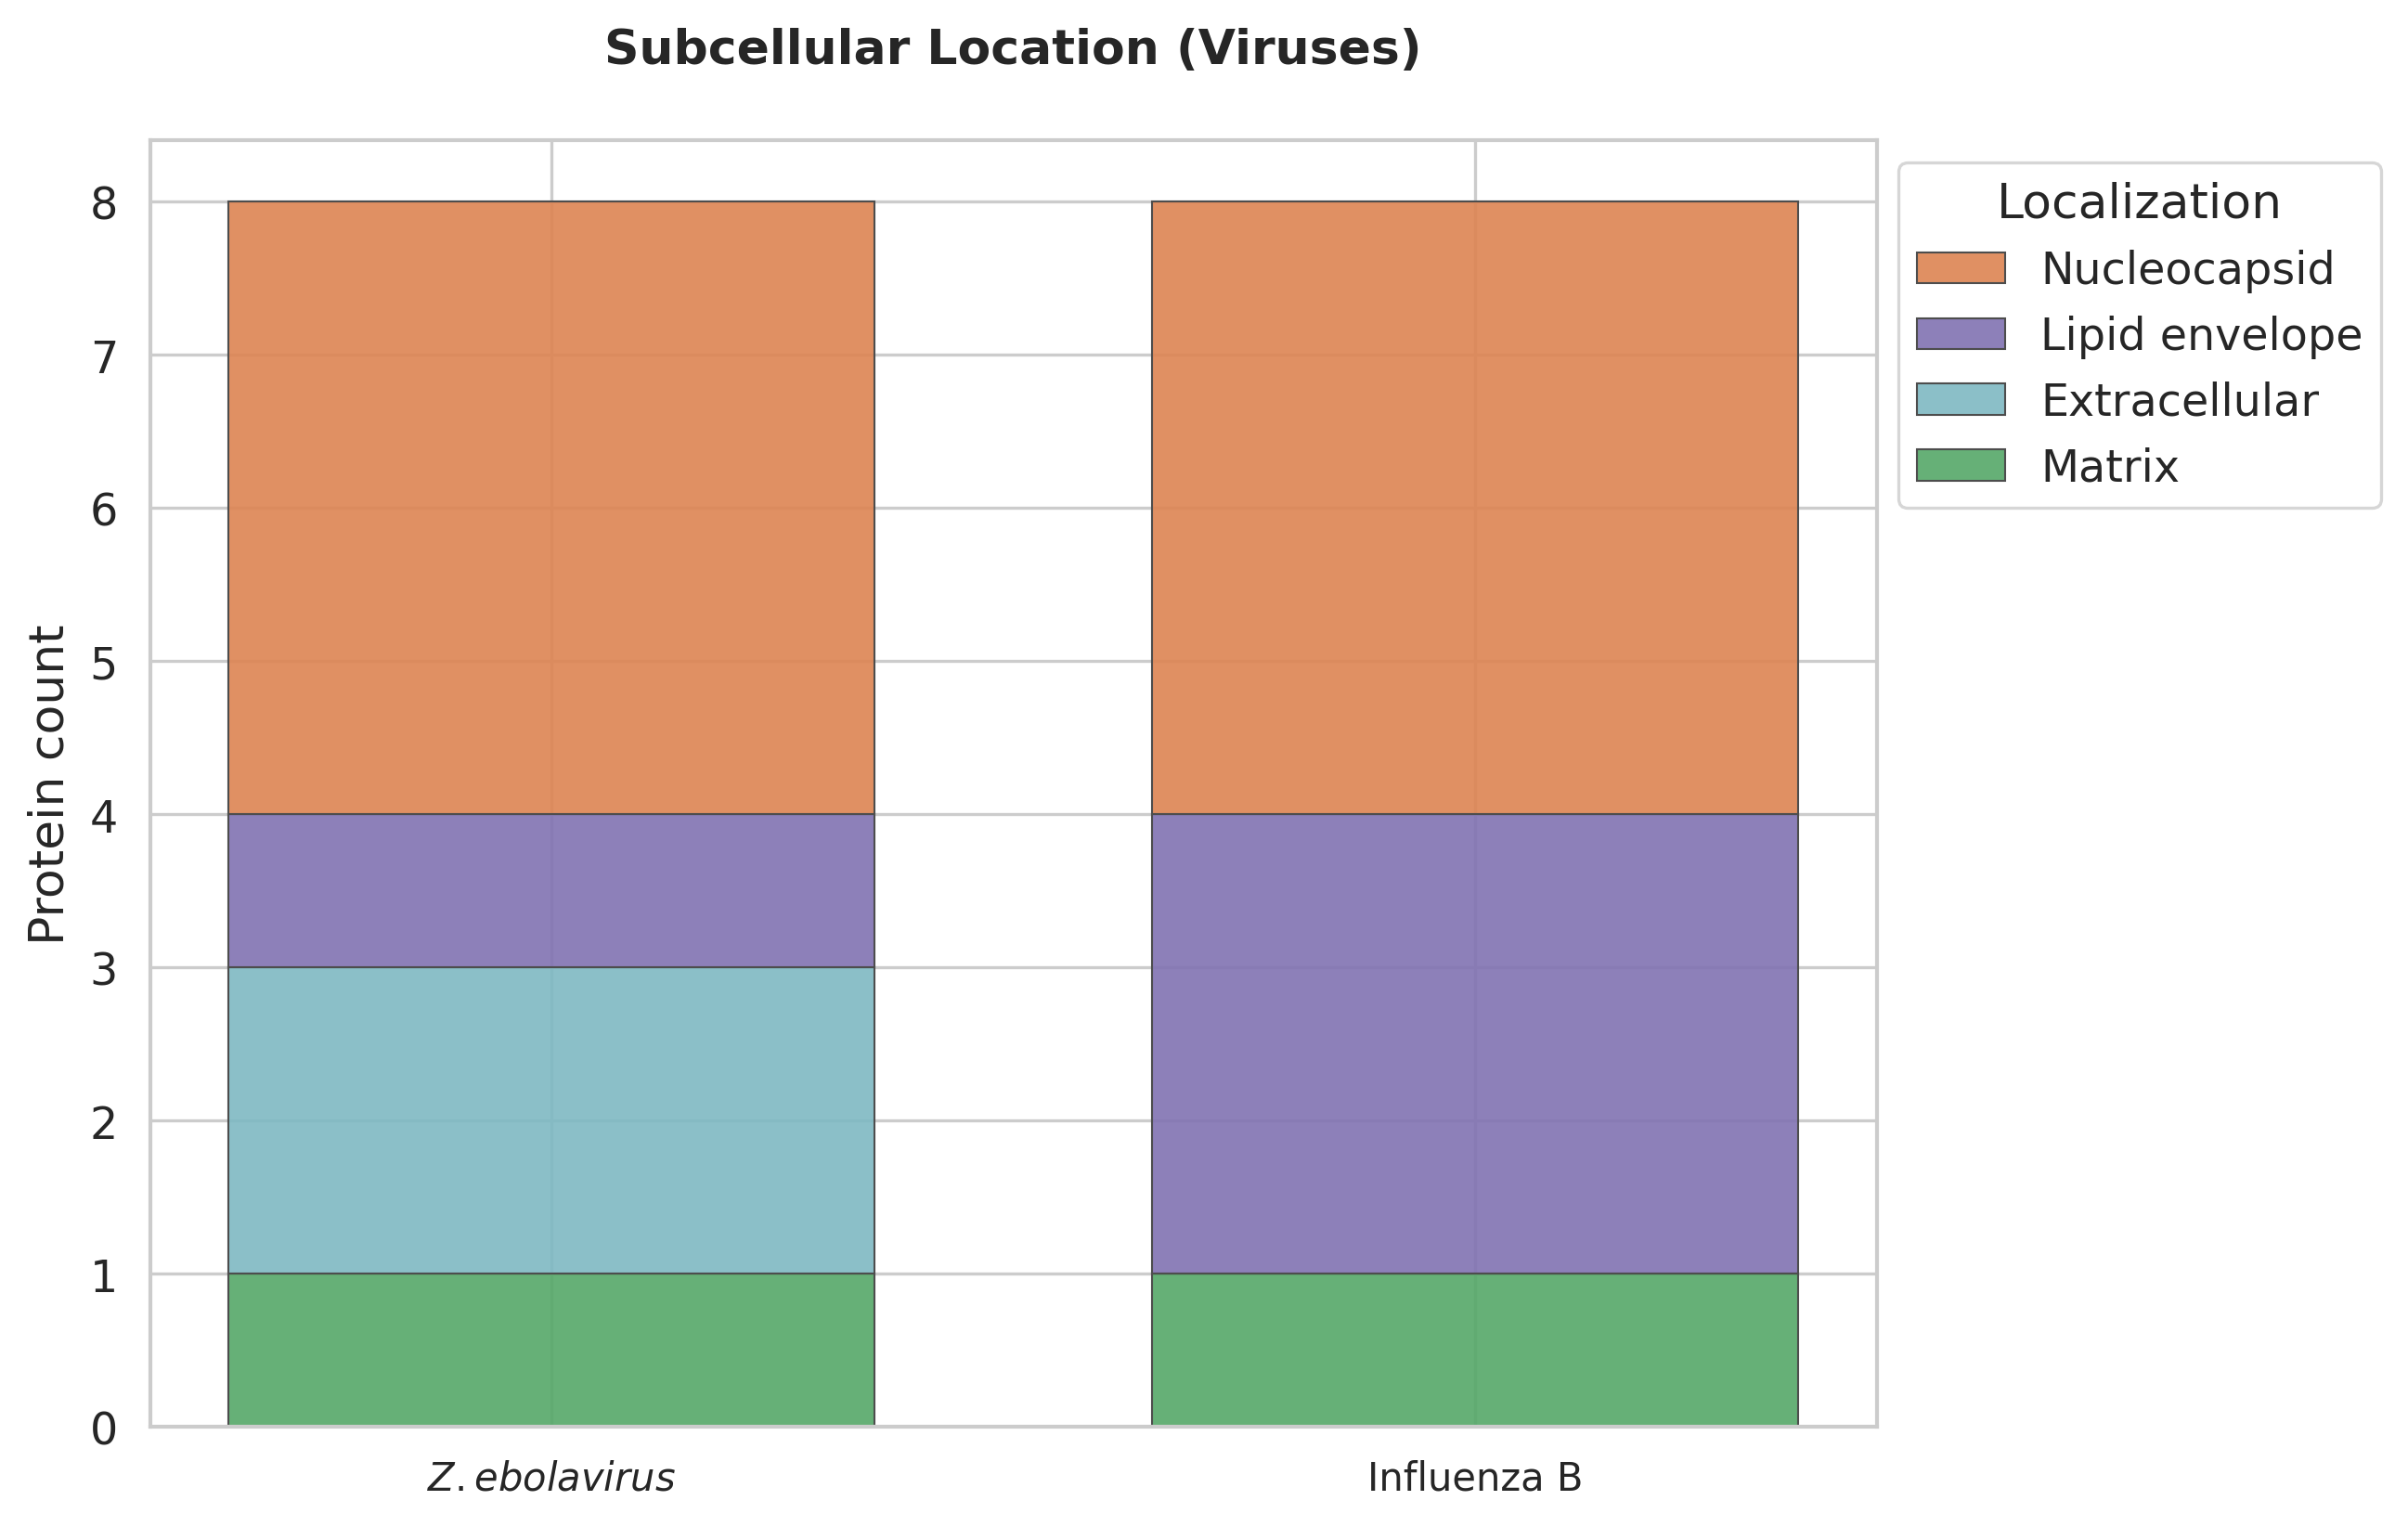

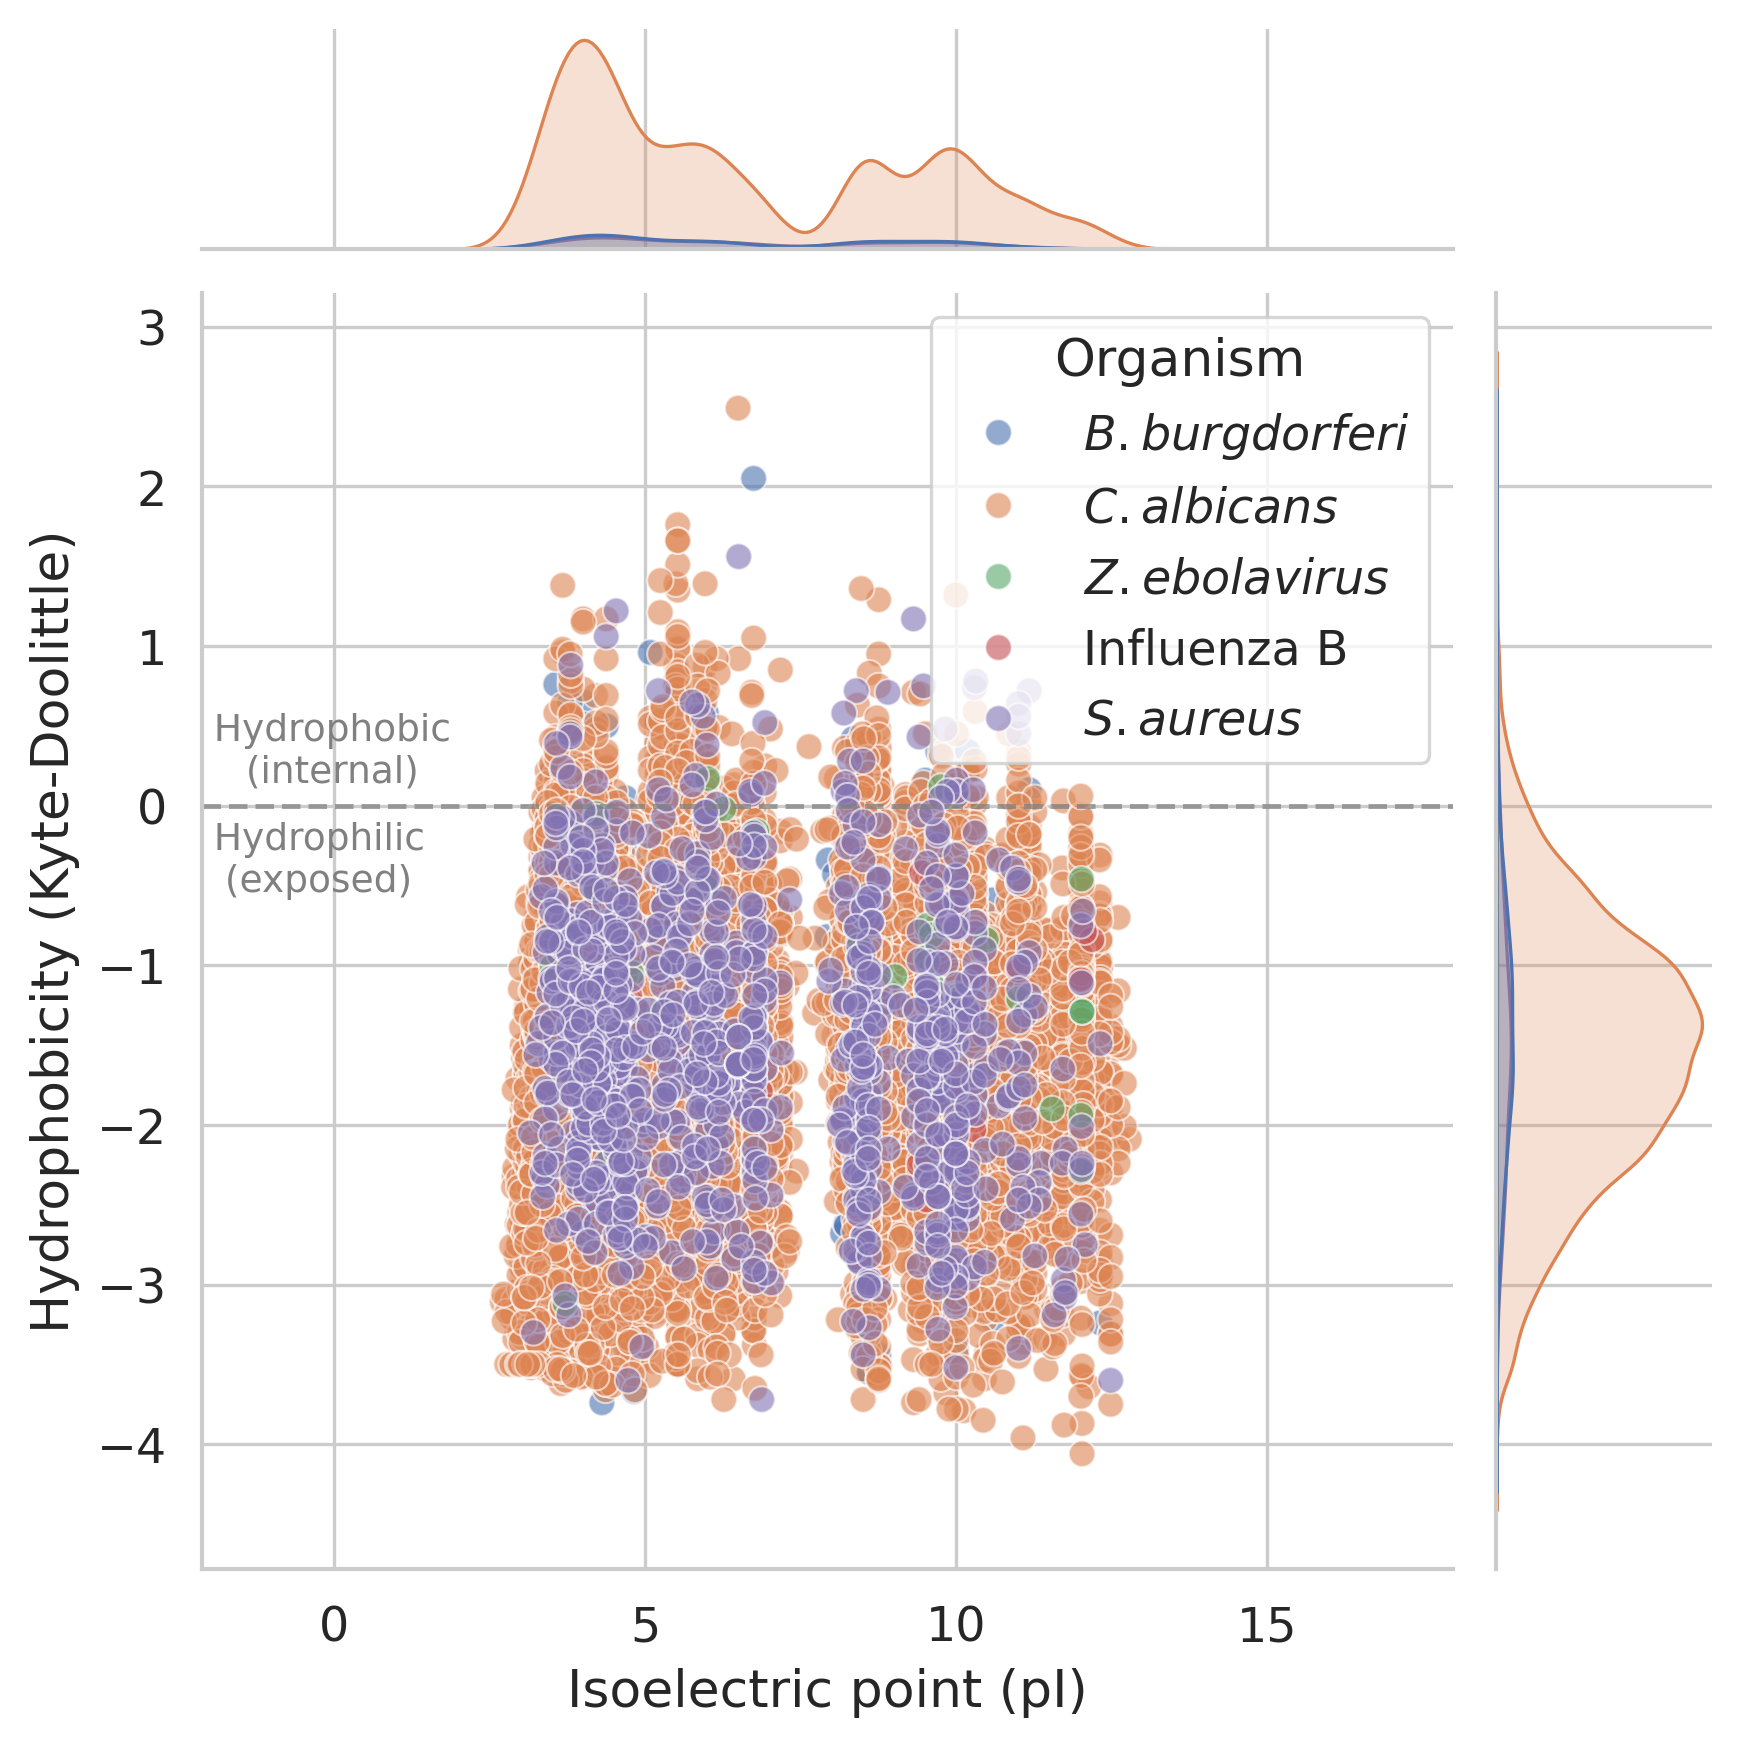

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)


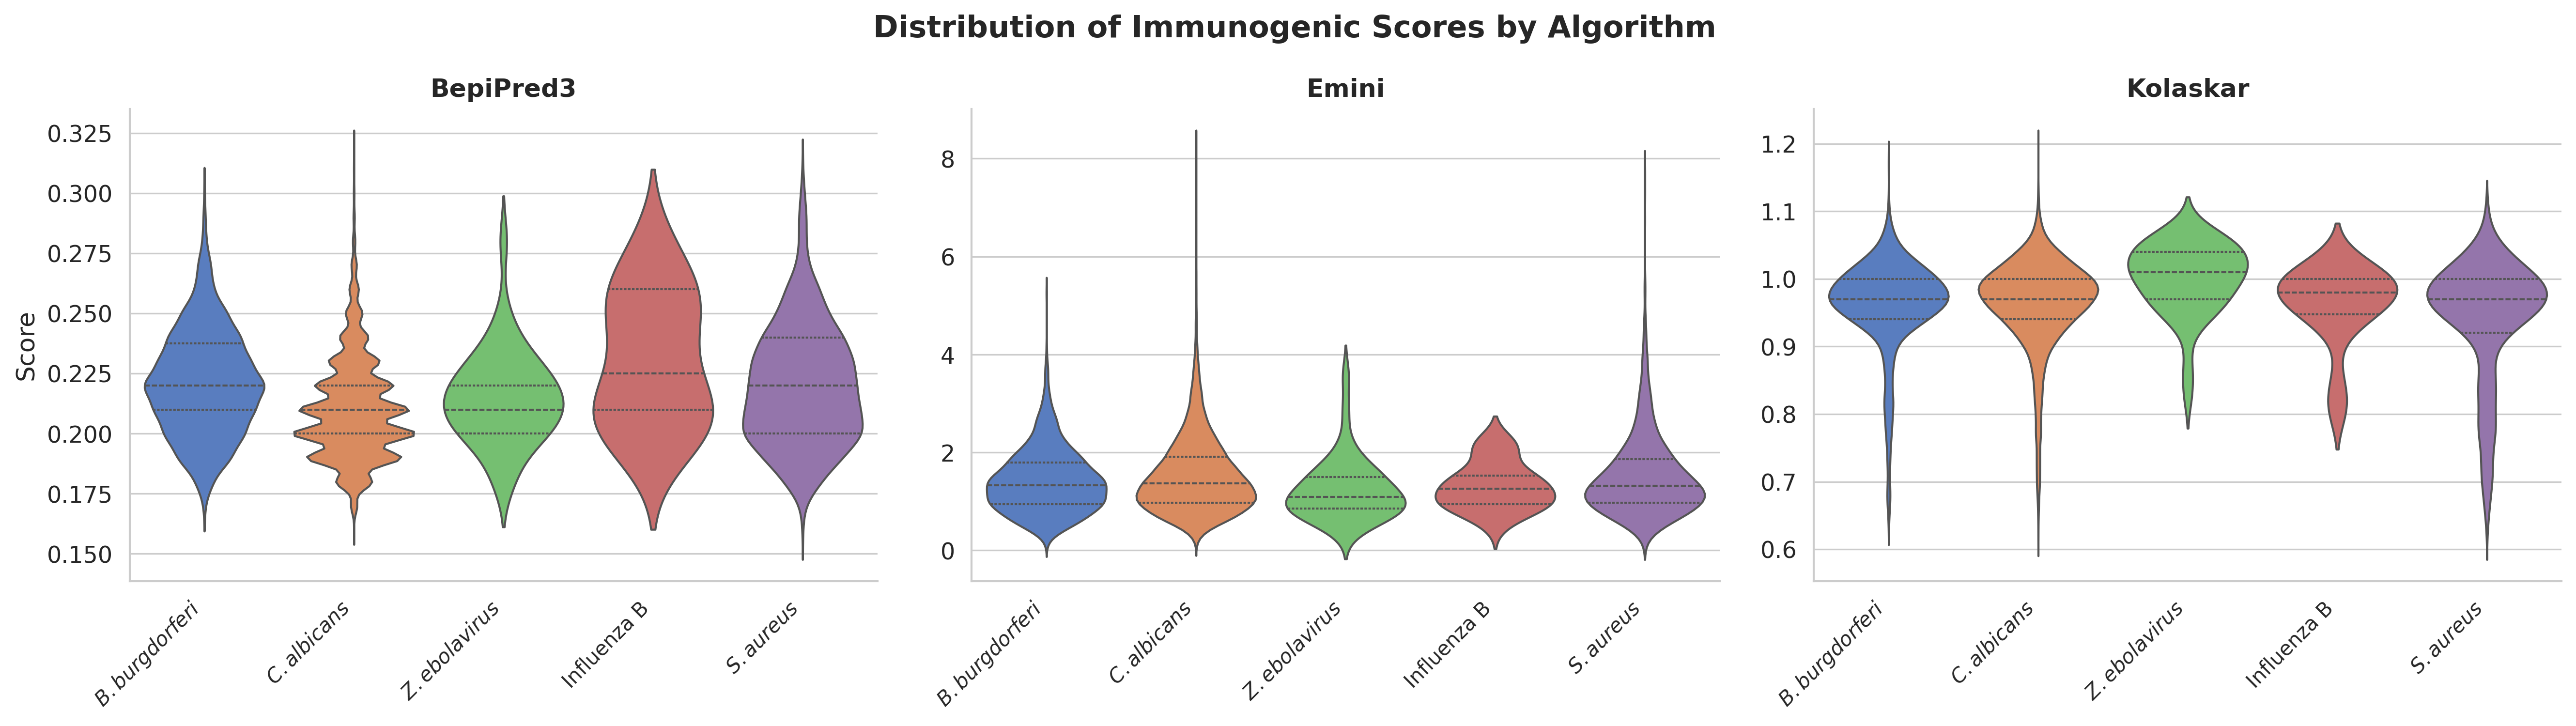


--- Top 3 Candidatos por Organismo (BepiPred Alto + Hidrofílico) ---


,Organism,Id,Epitope,BepiPred3,Hydropathy
0,$\mathit{B. burgdorferi}$,B5RL81,NKSKSKLIKSQQSPK,0.23,-1.77
1,$\mathit{B. burgdorferi}$,B5RN70,KKYEPYSLDSKHD,0.24,-2.11
2,$\mathit{B. burgdorferi}$,B5RN69,KKYEPYSLDSKHD,0.22,-2.11
1122,$\mathit{C. albicans}$,Q5AH90,YQQPPPQQQQYPQSPHK,0.24,-2.53
1123,$\mathit{C. albicans}$,A0A1D8PGL7,SLQSQPQPQPQPQPQPQ,0.23,-2.08
1124,$\mathit{C. albicans}$,A0A1D8PCR0,TPQQPPPPPPRKQ,0.21,-2.37
15183,$\mathit{Z. ebolavirus}$,Q5XX01,QGDSRNDRTTTTRFPPKSRSTPTS,0.20,-1.90
15184,$\mathit{Z. ebolavirus}$,Q7T9D9,PEAQTPTTHTSGPS,0.20,-1.29
15185,$\mathit{Z. ebolavirus}$,Q5XX06,TPDYDDCHSPAS,0.21,-1.35
15220,Influenza B,Q9QLL6,DDFSSTETEK,0.19,-1.81


In [36]:
# --- 1. DEFINIÇÕES DE LOCALIZAÇÃO POR DOMÍNIO ---
LOCALIZATIONS_EUCARIOTO = [
    'Cytosol', 'Endoplasmic Reticulum', 'Extracellular',
    'Golgi apparatus', 'Mitochondrion', 'Nucleus',
    'Peroxisome', 'Plasma membrane', 'Unknown'
]

LOCALIZATIONS_PROCARIOTO = [
    'Cytoplasmic', 'Cytoplasmic membrane', 'Extracellular',
    'Outer membrane', 'Periplasmic', 'Unknown', 'Cell wall'
]

LOCALIZATIONS_VIRUS = [
    'Nucleocapsid', 'Lipid envelope', 'Matrix', 'Extracellular', 'Unknown'
]

# --- 2. FORMATAÇÃO DOS NOMES ---
mapa_nomes_grafico = {
    'Borrelia': r'$\mathit{B. burgdorferi}$',
    'Staphylococcus': r'$\mathit{S. aureus}$',
    'Candida': r'$\mathit{C. albicans}$',
    'Ebola': r'$\mathit{Z. ebolavirus}$',
    'Influenza': 'Influenza B'
}

# --- 3. FUNÇÃO DE PLOTAGEM CENTRALIZADA ---
def plot_localization_stacked(df_plot, title, color_map, allowed_localizations, translation_dict, file_name):
    if df_plot.empty:
        print(f"Não há dados para: {title}")
        return

    df_filtered = df_plot[df_plot['Localization'].isin(allowed_localizations)].copy()
    if df_filtered.empty:
        return

    loc_counts = df_filtered['Localization'].value_counts()
    loc_order = loc_counts.index.tolist()
    palette = {loc: color_map.get(loc, 'gray') for loc in loc_order}

    plt.figure(figsize=(max(8, len(df_filtered['Organism'].unique()) * 3), 6))

    # Plotagem principal
    ax = sns.histplot(
        data=df_filtered,
        x="Organism",
        hue="Localization",
        multiple="stack",
        alpha=0.9,
        palette=palette,
        hue_order=loc_order,
        edgecolor=".3",
        linewidth=.5,
        shrink=0.7,
        legend=True
    )

    ax.set_xticks(ax.get_xticks())
    labels = [l.get_text() for l in ax.get_xticklabels()]
    new_labels = [translation_dict.get(text, text) for text in labels]
    ax.set_xticklabels(new_labels, rotation=0, ha='center', fontsize=10)

    sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), title="Localization")
    plt.title(title, fontweight='bold', pad=20)
    plt.ylabel("Protein count")
    plt.xlabel("")

    plt.savefig(file_name, dpi=600, bbox_inches='tight')
    print(f"Gráfico salvo: {file_name}")
    plt.show()

# --- 4. EXECUÇÃO E FILTRAGEM ---

if 'df_summary' in locals() and not df_summary.empty:

    # Definição Manual das Cores
    color_map_global = {
            # Cores Comuns / Membranas:
            'Extracellular':        '#7eb8c2', #Verde Claro
            'Unknown':              '#a48fb3', #Lilás

            # Cores Procariotos:
            'Cytoplasmic':          '#4C72B0', #Azul
            'Cytoplasmic membrane': '#DD8452', #Laranja
            'Outer membrane':       '#55A868', #Verde
            'Periplasmic':          '#C44E52', #Vermelho
            'Cell wall':            '#8172B2', #Roxo

            # Cores Eucariotos:
            'Cytosol':              '#4C72B0', #Azul
            'Plasma membrane':      '#DD8452', #Laranja
            'Mitochondrion':        '#55A868', #Verde
            'Nucleus':              '#8172B2', #Roxo
            'Endoplasmic Reticulum':'#C44E52', #Vermelho
            'Golgi apparatus':      '#da8bc3', #Rosa
            'Peroxisome':           '#64b5cd', #Azul claro

            # Cores Vírus:
            'Nucleocapsid':         '#DD8452', #Laranja
            'Lipid envelope':       '#8172B2', #Roxo
            'Matrix':               '#55A868'  #Verde
        }


    # --- SEÇÃO A: GRÁFICOS DE BARRA (LOCALIZAÇÃO) ---
    df_euc  = df_summary[df_summary['Organism'].isin(['Candida'])]
    df_proc = df_summary[df_summary['Organism'].isin(['Borrelia', 'Staphylococcus'])]
    df_vir  = df_summary[df_summary['Organism'].isin(['Ebola', 'Influenza'])]

    plot_localization_stacked(df_proc, "Subcellular Location (Prokaryotes)", color_map_global, LOCALIZATIONS_PROCARIOTO, mapa_nomes_grafico, "plot_A_prokaryotes.png")
    plot_localization_stacked(df_euc, "Subcellular Location (Eukaryotes)", color_map_global, LOCALIZATIONS_EUCARIOTO, mapa_nomes_grafico, "plot_A_eukaryotes.png")
    plot_localization_stacked(df_vir, "Subcellular Location (Viruses)", color_map_global, LOCALIZATIONS_VIRUS, mapa_nomes_grafico, "plot_A_viruses.png")

    # --- SEÇÃO B: LANDSCAPE FÍSICO-QUÍMICO ---
    df_temp_b = df_detailed.copy()
    df_temp_b['Organism'] = df_temp_b['Organism'].replace(mapa_nomes_grafico)

    g = sns.JointGrid(data=df_temp_b, x="I.P", y="Hydropathy", hue="Organism", palette="deep")
    g.plot_joint(sns.scatterplot, s=40, alpha=0.6, edgecolor="white")
    g.plot_marginals(sns.kdeplot, fill=True)
    g.set_axis_labels("Isoelectric point (pI)", "Hydrophobicity (Kyte-Doolittle)")
    g.ax_joint.axhline(0, color='gray', linestyle='--', linewidth=1.2, alpha=0.7)

    x0 = g.ax_joint.get_xlim()[0]

    g.ax_joint.text(x0, 0.1, " Hydrophobic\n (internal)", fontsize=9, color='gray', va='bottom', multialignment='center')
    g.ax_joint.text(x0, -0.1, " Hydrophilic\n (exposed)", fontsize=9, color='gray', va='top', multialignment='center')

    plt.savefig("plot_B_landscape.png", dpi=600, bbox_inches='tight')
    plt.show()

    # --- SEÇÃO C: SCORES DE PREDIÇÃO ---
    metrics = ['BepiPred3', 'Emini', 'Kolaskar']
    existing_metrics = [m for m in metrics if m in df_detailed.columns]

    if existing_metrics:
        df_melted = df_detailed.melt(id_vars=['Organism'], value_vars=existing_metrics, var_name='Metodo', value_name='Score')
        g = sns.FacetGrid(df_melted, col="Metodo", sharey=False, height=5, aspect=1.2)
        g.map_dataframe(sns.violinplot, x="Organism", y="Score", palette="muted", inner="quartile")

        for ax in g.axes.flat:
            ax.set_xticks(ax.get_xticks())
            labels = [mapa_nomes_grafico.get(l.get_text(), l.get_text()) for l in ax.get_xticklabels()]
            ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)

        g.set_axis_labels("", "Score")
        g.set_titles("{col_name}", fontweight='bold')
        plt.subplots_adjust(top=0.85, bottom=0.2)
        g.fig.suptitle("Distribution of Immunogenic Scores by Algorithm", fontweight='bold', y=0.98)

        plt.savefig("plot_C_scores.png", dpi=600, bbox_inches='tight')
        plt.show()

    # --- FINALIZAÇÃO: TOP CANDIDATOS ---
    print("\n--- Top 3 Candidatos por Organismo (BepiPred Alto + Hidrofílico) ---")
    best_candidates = df_detailed[(df_detailed['BepiPred3'] > 0.15) & (df_detailed['Hydropathy'] < 0)].copy()
    best_candidates['Organism'] = best_candidates['Organism'].replace(mapa_nomes_grafico)
    top_summary = best_candidates.groupby('Organism').head(3)[['Organism', 'Id', 'Epitope', 'BepiPred3', 'Hydropathy']]
    display(top_summary)

else:
    print("❌ Erro: Certifique-se de que os nomes no arquivo original são exatamente 'Borrelia', 'Staphylococcus', 'Candida', 'Ebola' e 'Influenza'.")


Instalando biblioteca upsetplot...
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


/usr/local/lib/python3.12/dist-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/usr/local/lib/python3.12/dist-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/usr/local/lib/

Gerando UpSet Plot...
Gráfico UpSet Plot salvo em alta resolução como: upset_plot_epitopos_compartilhados.png


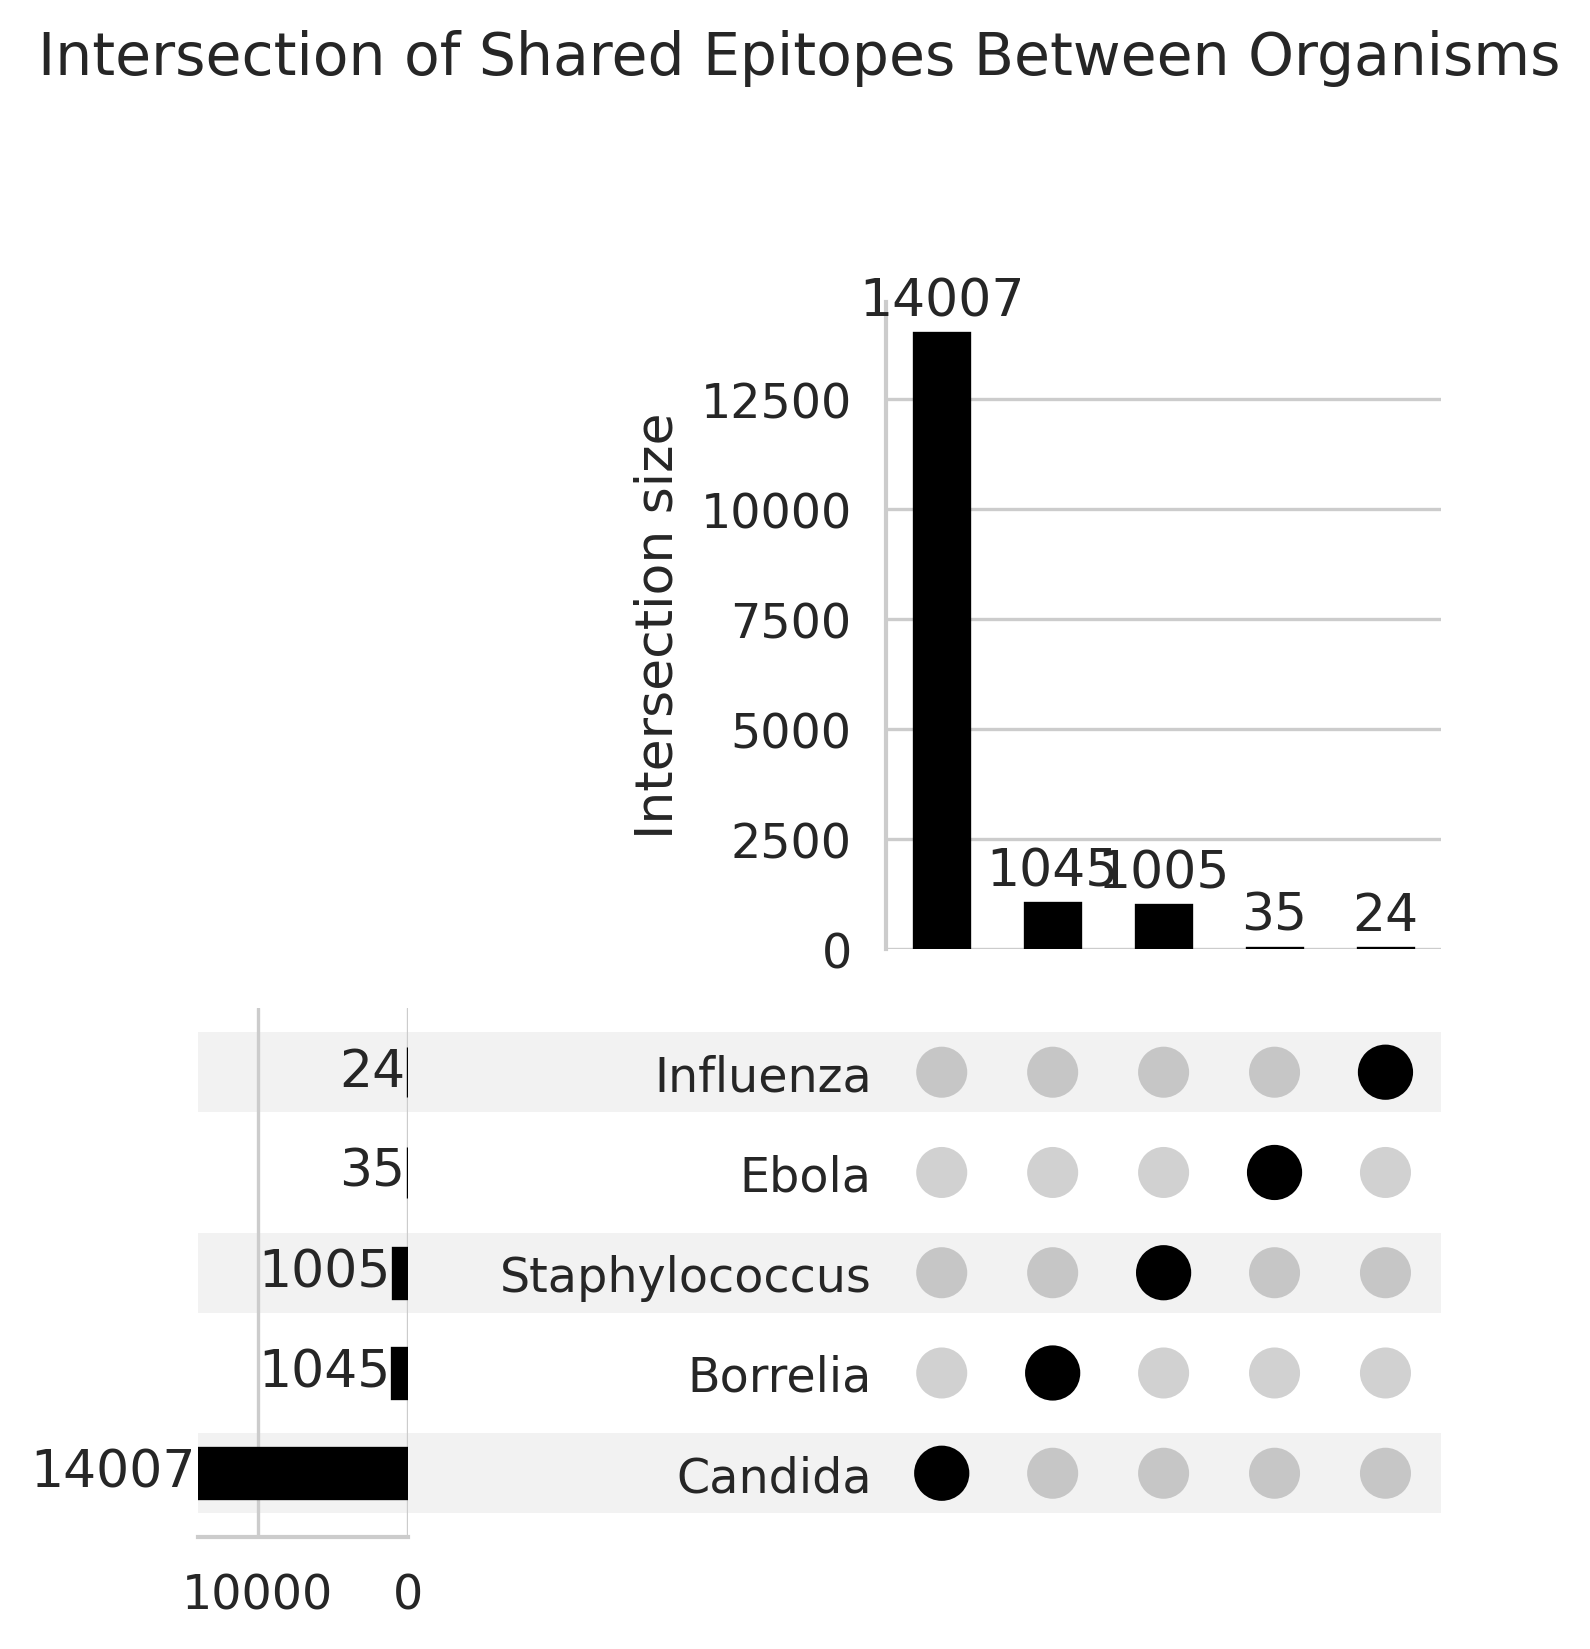

In [ ]:
# --- BLOCO EXTRA: UPSET PLOT ---

try:
    import upsetplot
except ImportError:
    print("Instalando biblioteca upsetplot...")
    !pip install upsetplot -q
    import upsetplot

from upsetplot import from_contents, UpSet
import matplotlib.pyplot as plt

if 'df_detailed' in locals() and not df_detailed.empty:
    dados_upset = df_detailed.groupby('Organism')['Epitope'].apply(set).to_dict()

    upset_data = from_contents(dados_upset)

    print("Gerando UpSet Plot...")
    fig = plt.figure(figsize=(10, 6))

    # Configuração do gráfico
    upset = UpSet(
        upset_data,
        subset_size='count',
        show_counts=True,
        sort_by='cardinality',
        element_size=35
    )

    # Renderiza
    upset.plot(fig=fig)
    plt.suptitle("Intersection of Shared Epitopes Between Organisms", y=1.05, fontsize=14)

    # --- SALVAR EM ALTA RESOLUÇÃO ---
    file_name_upset = 'upset_plot_epitopos_compartilhados.png'

    plt.savefig(
        file_name_upset,
        dpi=600,
        bbox_inches='tight',
        format='png'
    )
    print(f"Gráfico UpSet Plot salvo em alta resolução como: {file_name_upset}")
    plt.show()

else:
    print("Erro: A variável 'df_detailed' não foi encontrada. Rode o script de importação primeiro.")

/tmp/ipython-input-1204763333.py:29: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_merged['Has_Epitope'] = df_merged['Has_Epitope'].fillna(False)
/tmp/ipython-input-1204763333.py:29: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_merged['Has_Epitope'] = df_merged['Has_Epitope'].fillna(False)
/tmp/ipython-input-1204763333.py:29: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option(


--- GRÁFICO 1: OUTROS ORGANISMOS (Proteomas Maiores) ---
Gráfico 'Membrane protein count and predicted epitope ratio (Bacteria and Fungi)' salvo em alta resolução como: abundancia_epitopos_outros.png


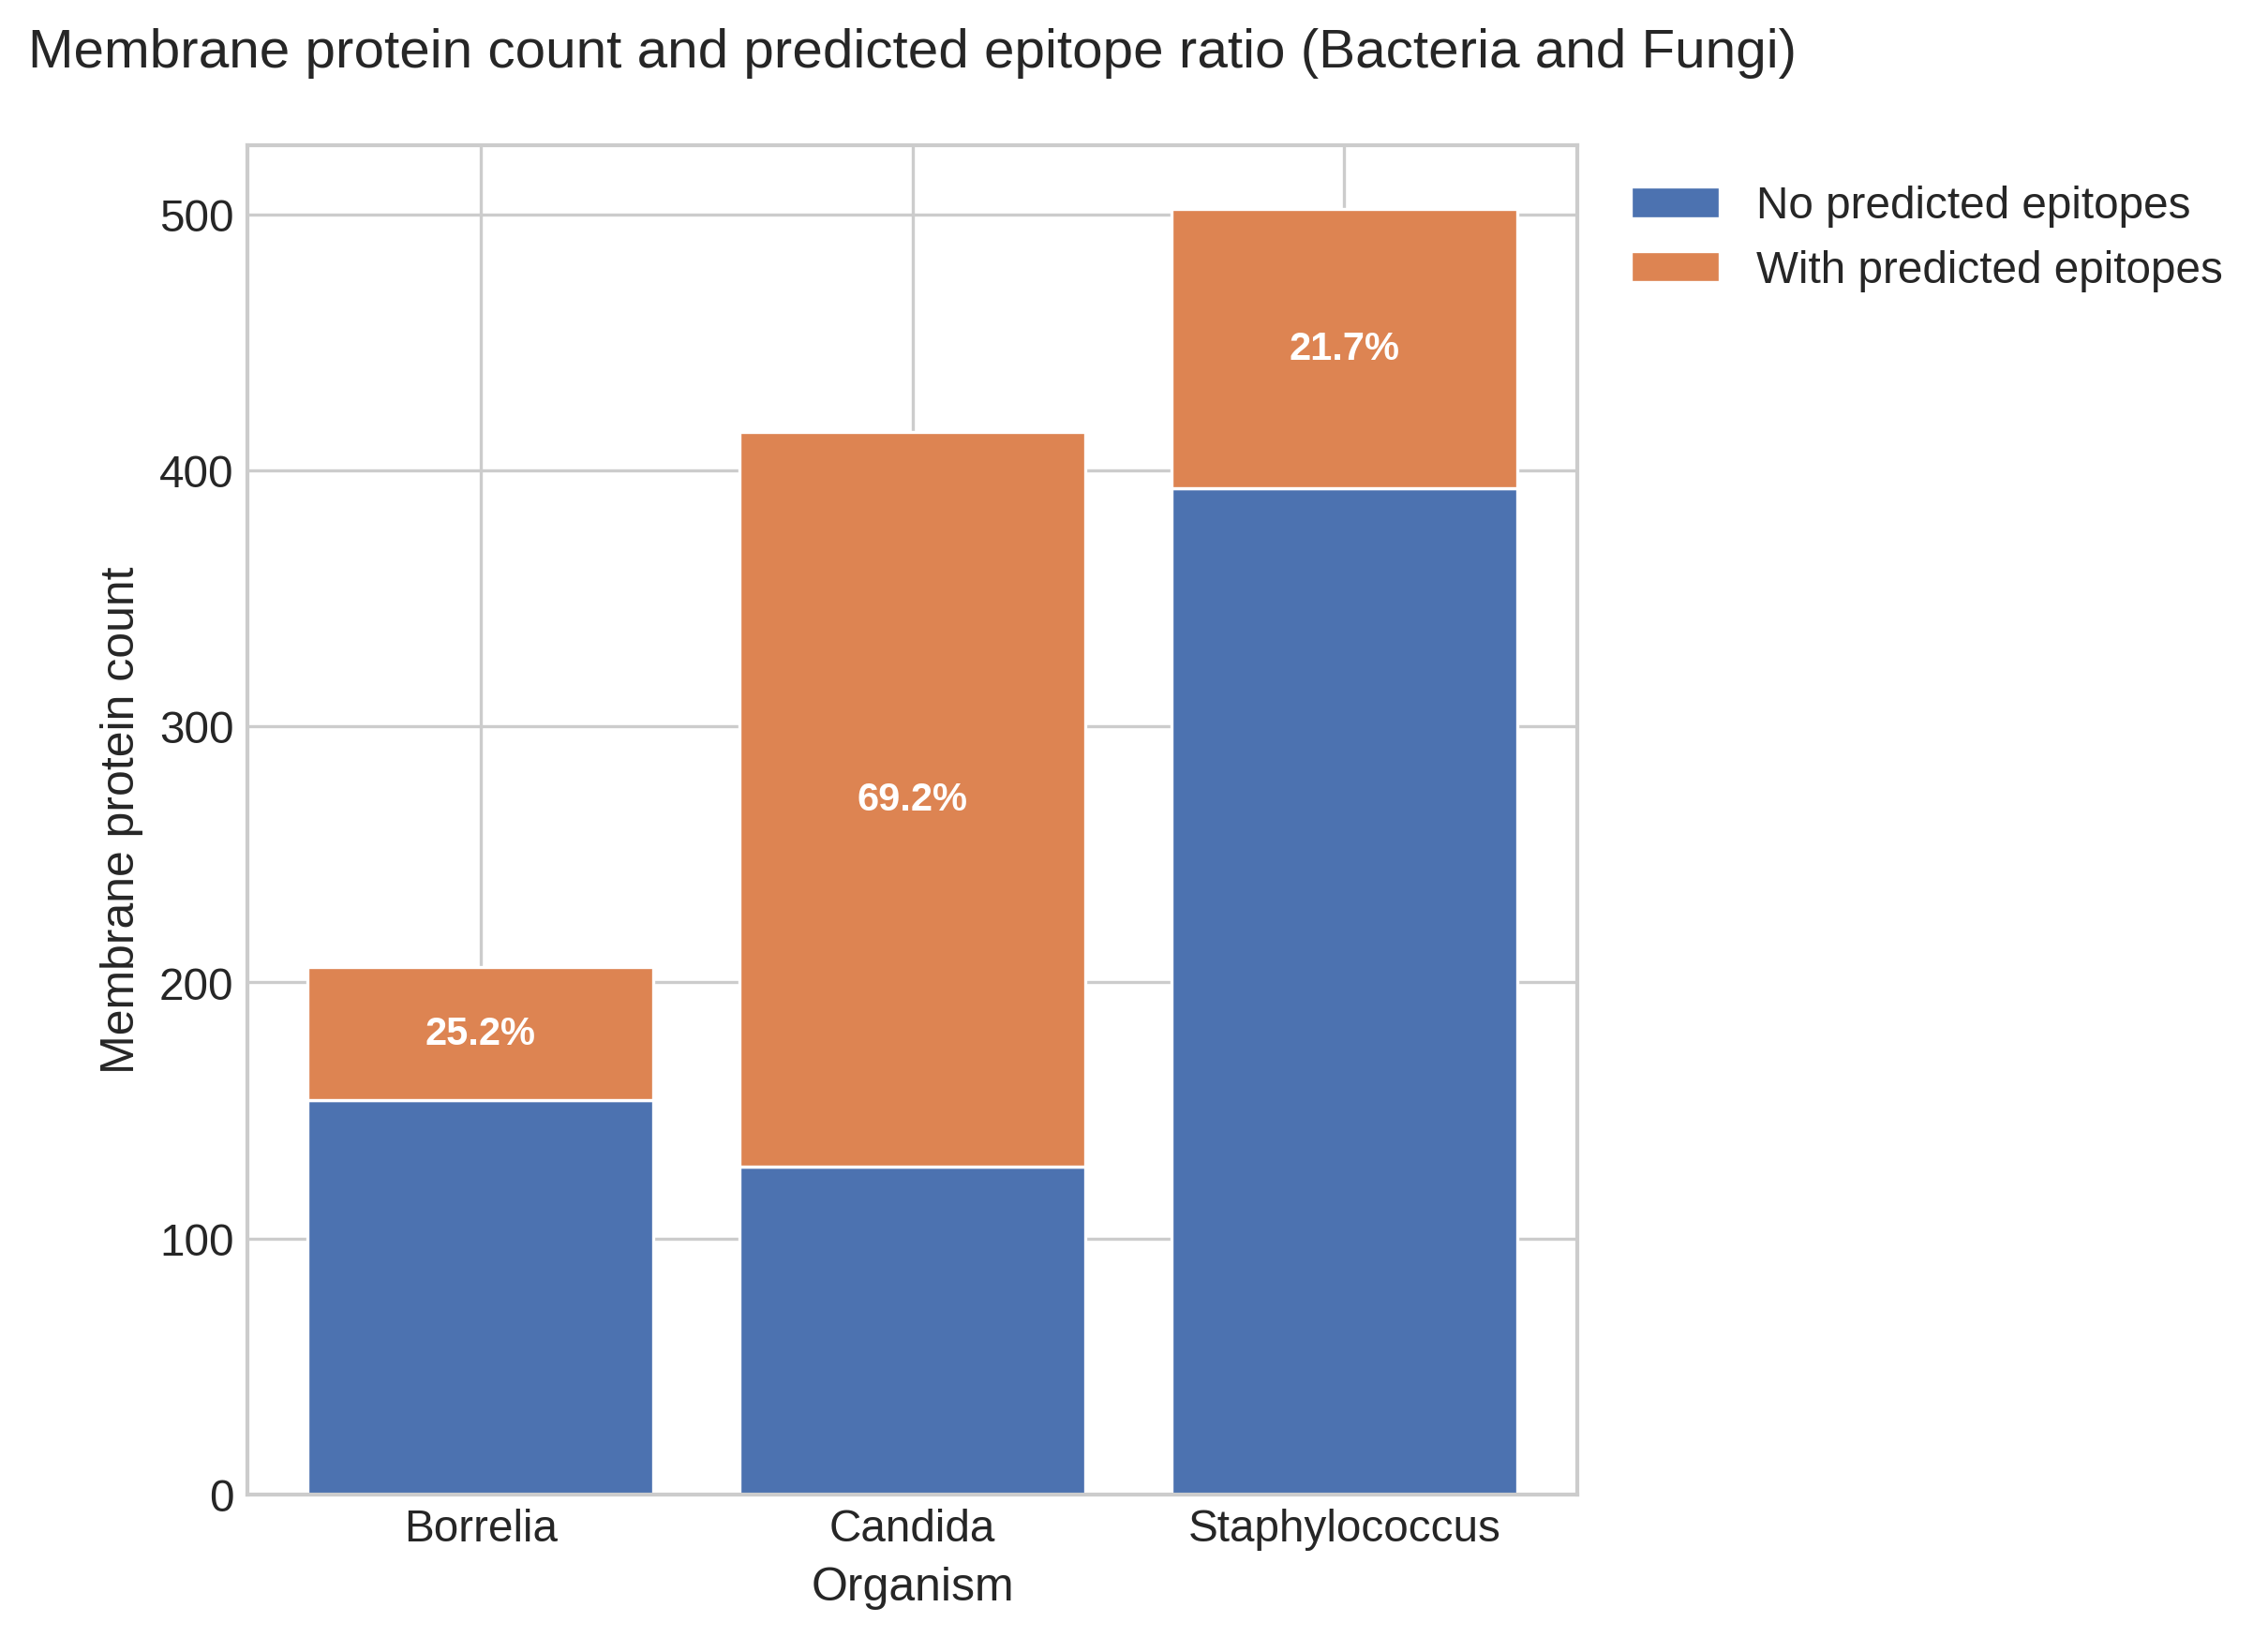


--- GRÁFICO 2: VÍRUS (Proteomas Menores) ---
Gráfico 'Membrane protein count and predicted epitope ratio (Viruses)' salvo em alta resolução como: abundancia_epitopos_virus.png


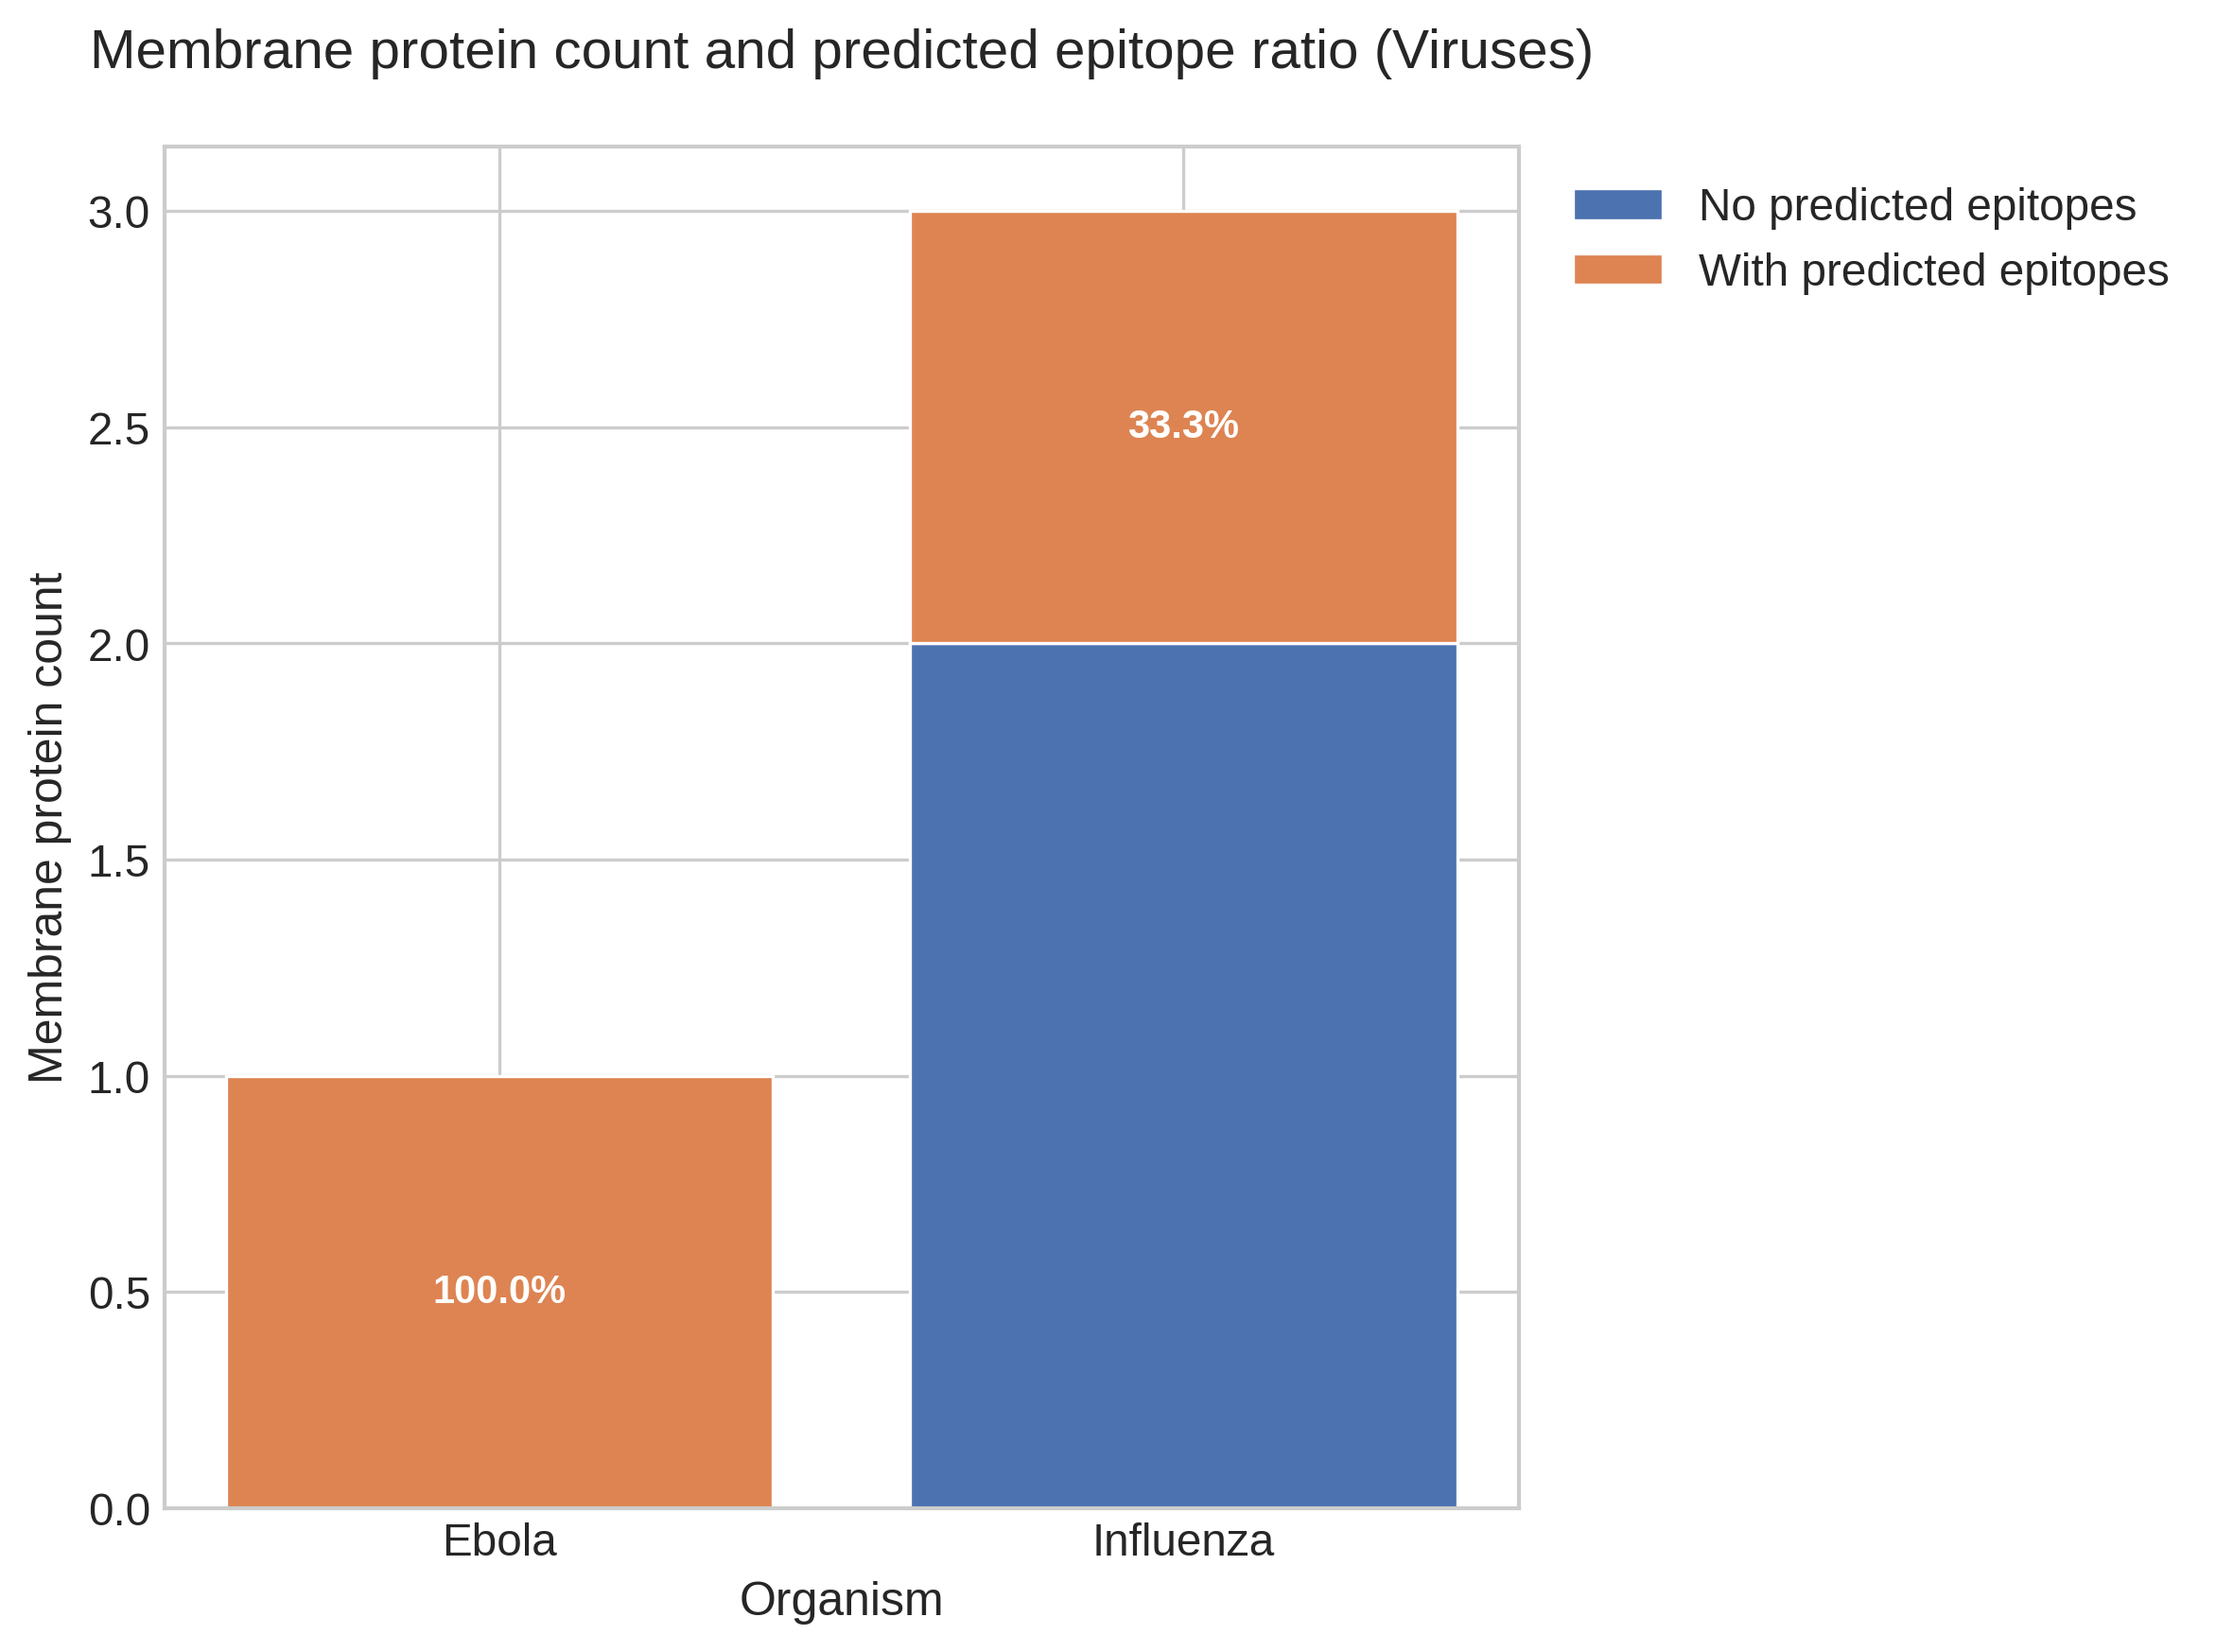


### RESULTADO CONSOLIDADO DA ANÁLISE (TODOS OS ORGANISMOS) ###
      Organism  Total Proteinas  Proteinas Membrana % Membrana (Total)  Membrana c/ Epitopos % Membrana c/ Epitopos (do Total Membrana) % Enriquecimento (Membrana no Total c/ Epitopos)
      Borrelia             1148                 206             17.94%                    52                                     25.24%                                           16.10%
       Candida             3701                 415             11.21%                   287                                     69.16%                                           11.90%
         Ebola                8                   1             12.50%                     1                                    100.00%                                           12.50%
     Influenza                8                   3             37.50%                     1                                     33.33%                                           20.00%
Staphylococ

In [ ]:
KEYWORD_MEMBRANA = 'Plasma membrane|Cytoplasmic membrane|Outer membrane|Cell wall|Lipid envelope'
COLUNA_ID = 'Id'
VIRUS = ['Ebola', 'Influenza']

# --- FUNÇÃO DE CÁLCULO DE MÉTRICAS ---

def calcular_metricas(df_sum, df_det, organism_name, keyword_membrana, coluna_id):
    """Realiza a mesclagem e os cálculos de porcentagem para um único organismo."""

    # Identificar Proteínas de Membrana (Anotação)
    df_sum['Is_Membrane'] = df_sum['Localization'].astype(str).str.contains(
        keyword_membrana,
        case=False,
        na=False,
        regex=True
    )

    # Identificar Proteínas com Epítopos
    if not df_det.empty:
        epitopes_counts = df_det.groupby(coluna_id).size().reset_index(name='Epitopes_Count')
        epitopes_counts['Has_Epitope'] = epitopes_counts['Epitopes_Count'] > 0
    else:
        epitopes_counts = pd.DataFrame({coluna_id: df_sum[coluna_id].unique(), 'Has_Epitope': False})

    df_merged = pd.merge(df_sum, epitopes_counts[[coluna_id, 'Has_Epitope']], on=coluna_id, how='left')
    df_merged['Has_Epitope'] = df_merged['Has_Epitope'].fillna(False)

    # Cálculos
    TOTAL_PROTEINS = len(df_merged)
    membrane_proteins = df_merged['Is_Membrane'].sum()
    membrane_with_epitopes = df_merged[df_merged['Is_Membrane']]['Has_Epitope'].sum()
    all_proteins_with_epitopes = df_merged['Has_Epitope'].sum()

    # % Membrana (Total)
    perc_membrane_total = (membrane_proteins / TOTAL_PROTEINS) * 100 if TOTAL_PROTEINS > 0 else 0

    # % Membrana c/ Epitopos (do Total Membrana)
    perc_membrane_with_epitopes = (membrane_with_epitopes / membrane_proteins) * 100 if membrane_proteins > 0 else 0

    # % Enriquecimento (Membrana no Total Geral c/ Epítopos)
    perc_enrichment = (membrane_with_epitopes / all_proteins_with_epitopes) * 100 if all_proteins_with_epitopes > 0 else 0

    return {
        'Organism': organism_name,
        'Total Proteinas': TOTAL_PROTEINS,
        'Proteinas Membrana': membrane_proteins,
        '% Membrana (Total)': perc_membrane_total,
        'Membrana c/ Epitopos': membrane_with_epitopes,
        '% Membrana c/ Epitopos (do Total Membrana)': perc_membrane_with_epitopes,
        '% Enriquecimento (Membrana no Total c/ Epitopos)': perc_enrichment
    }

def analisar_proteomas_membrana(df_detailed, df_summary):
    """Itera sobre os organismos consolidados e aplica o cálculo de métricas."""
    if df_summary.empty:
        return pd.DataFrame()

    results_list = []

    for organism in df_summary['Organism'].unique():
        df_sum_org = df_summary[df_summary['Organism'] == organism].copy()
        df_det_org = df_detailed[df_detailed['Organism'] == organism].copy()

        if not df_sum_org.empty:
            metrics = calcular_metricas(
                df_sum_org,
                df_det_org,
                organism,
                KEYWORD_MEMBRANA,
                COLUNA_ID
            )
            results_list.append(metrics)

    return pd.DataFrame(results_list)


# --- GERAÇÃO DO GRÁFICO  ---

def plot_abundancia_membrana(df_plot, title, file_name=None):
    """
    Gera um gráfico de barras empilhadas para o subconjunto de dados fornecido,
    usando a paleta 'deep' e a escala Y adaptada ao subconjunto.
    """
    if df_plot.empty:
        print(f"Não há dados para plotar no gráfico: {title}")
        return

    df_plot['Proteinas Membrana'] = df_plot['Proteinas Membrana'].astype(int)
    df_plot['Membrana c/ Epitopos'] = df_plot['Membrana c/ Epitopos'].astype(int)
    df_plot['Membrana s/ Epitopos'] = df_plot['Proteinas Membrana'] - df_plot['Membrana c/ Epitopos']

    palette_deep = sns.color_palette("deep")
    COR_SEM_EPITOPO = palette_deep[0]
    COR_COM_EPITOPO = palette_deep[1]

    # Plotagem
    plt.style.use('seaborn-v0_8-whitegrid')
    fig_width = max(8, len(df_plot) * 1.5)
    fig, ax = plt.subplots(figsize=(fig_width, 6))

    organizadores = df_plot['Organism']

    # Plotar a seção SEM Epítopos
    ax.bar(organizadores, df_plot['Membrana s/ Epitopos'], label='No predicted epitopes', color=COR_SEM_EPITOPO)

    # Plotar a seção COM Epítopos (Empilhada no topo)
    ax.bar(organizadores, df_plot['Membrana c/ Epitopos'], bottom=df_plot['Membrana s/ Epitopos'], label='With predicted epitopes', color=COR_COM_EPITOPO)

    #Adicionar Rótulos de Porcentagem
    for i, row in df_plot.iterrows():
        perc_value = row['% Membrana c/ Epitopos (do Total Membrana)']
        y_pos = row['Membrana s/ Epitopos'] + (row['Membrana c/ Epitopos'] / 2)

        if row['Membrana c/ Epitopos'] > 0:
            ax.text(
                i,
                y_pos,
                f"{perc_value:.1f}%",
                ha='center',
                va='center',
                color='white',
                fontsize=10,
                fontweight='bold'
            )

    ax.set_title(title, fontsize=14, pad=20)
    ax.set_xlabel('Organism', fontsize=12)
    ax.set_ylabel('Membrane protein count', fontsize=12)
    ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1))
    plt.xticks(rotation=0)
    plt.tight_layout()

    if file_name:
        plt.savefig(
            file_name,
            dpi=600,
            bbox_inches='tight',
            format='png'
        )
        print(f"Gráfico '{title}' salvo em alta resolução como: {file_name}")

    plt.show()

# --- BLOCO DE EXECUÇÃO PRINCIPAL ---

if __name__ == '__main__':

    # CARREGAR DADOS BRUTOS
    df_detailed_final = df_detailed
    df_summary_final = df_summary

    if not df_summary_final.empty:

        # CALCULAR MÉTRICAS
        df_resultados = analisar_proteomas_membrana(df_detailed_final, df_summary_final)

        # Filtra o DataFrame para separar os grupos
        df_virus = df_resultados[df_resultados['Organism'].isin(VIRUS)].copy().reset_index(drop=True)
        df_outros = df_resultados[~df_resultados['Organism'].isin(VIRUS)].copy().reset_index(drop=True)

        # PLOTAGEM SEPARADA

        print("\n--- GRÁFICO 1: OUTROS ORGANISMOS (Proteomas Maiores) ---")
        plot_abundancia_membrana(
            df_outros,
            'Membrane protein count and predicted epitope ratio (Bacteria and Fungi)',
            file_name='abundancia_epitopos_outros.png'
        )

        print("\n--- GRÁFICO 2: VÍRUS (Proteomas Menores) ---")
        plot_abundancia_membrana(
            df_virus,
            'Membrane protein count and predicted epitope ratio (Viruses)',
            file_name='abundancia_epitopos_virus.png'
        )

        print("\n" + "="*80)
        print("### RESULTADO CONSOLIDADO DA ANÁLISE (TODOS OS ORGANISMOS) ###")
        print("="*80)

        df_display = df_resultados.copy()

        for col in df_display.columns:
            if '%' in col:
                df_display[col] = df_display[col].apply(lambda x: f"{x:.2f}%")

        print(df_display.to_string(index=False))

    else:
        print("Análise não executada devido a falha no carregamento dos dados.")

/tmp/ipython-input-1025507590.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sum['Has_Epitope'] = df_sum['Id'].isin(has_epi)


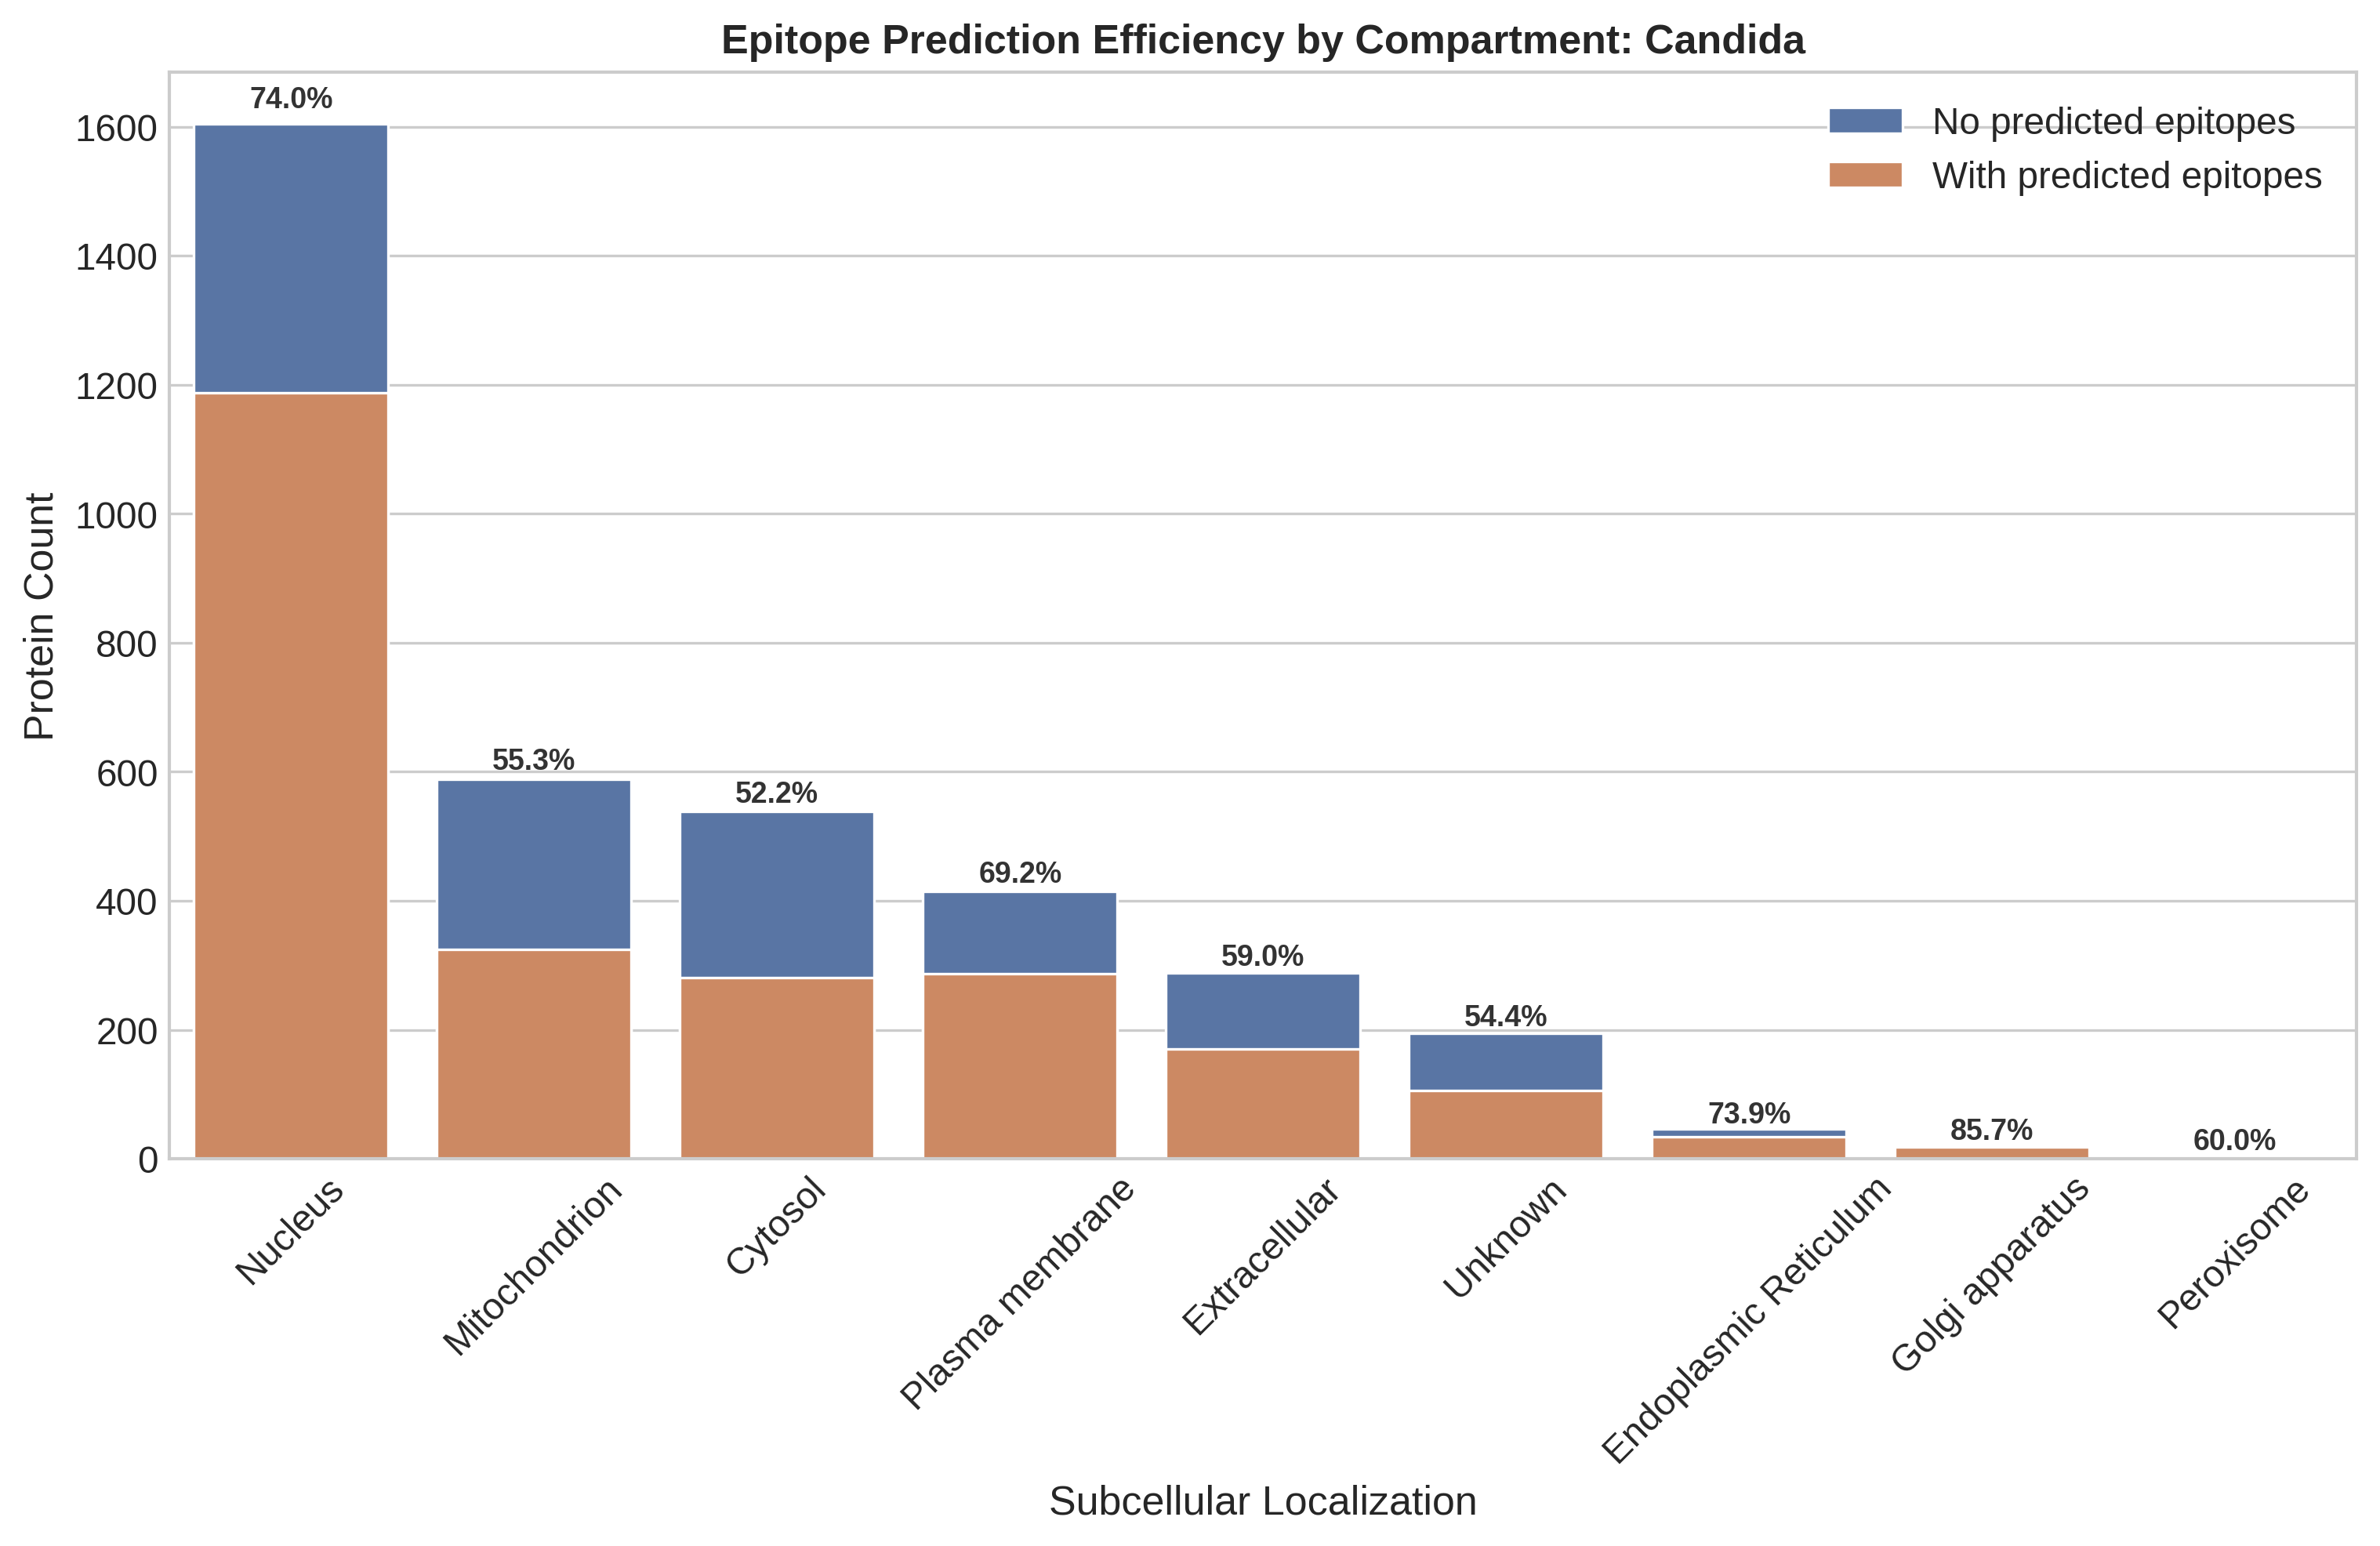

/tmp/ipython-input-1025507590.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sum['Has_Epitope'] = df_sum['Id'].isin(has_epi)


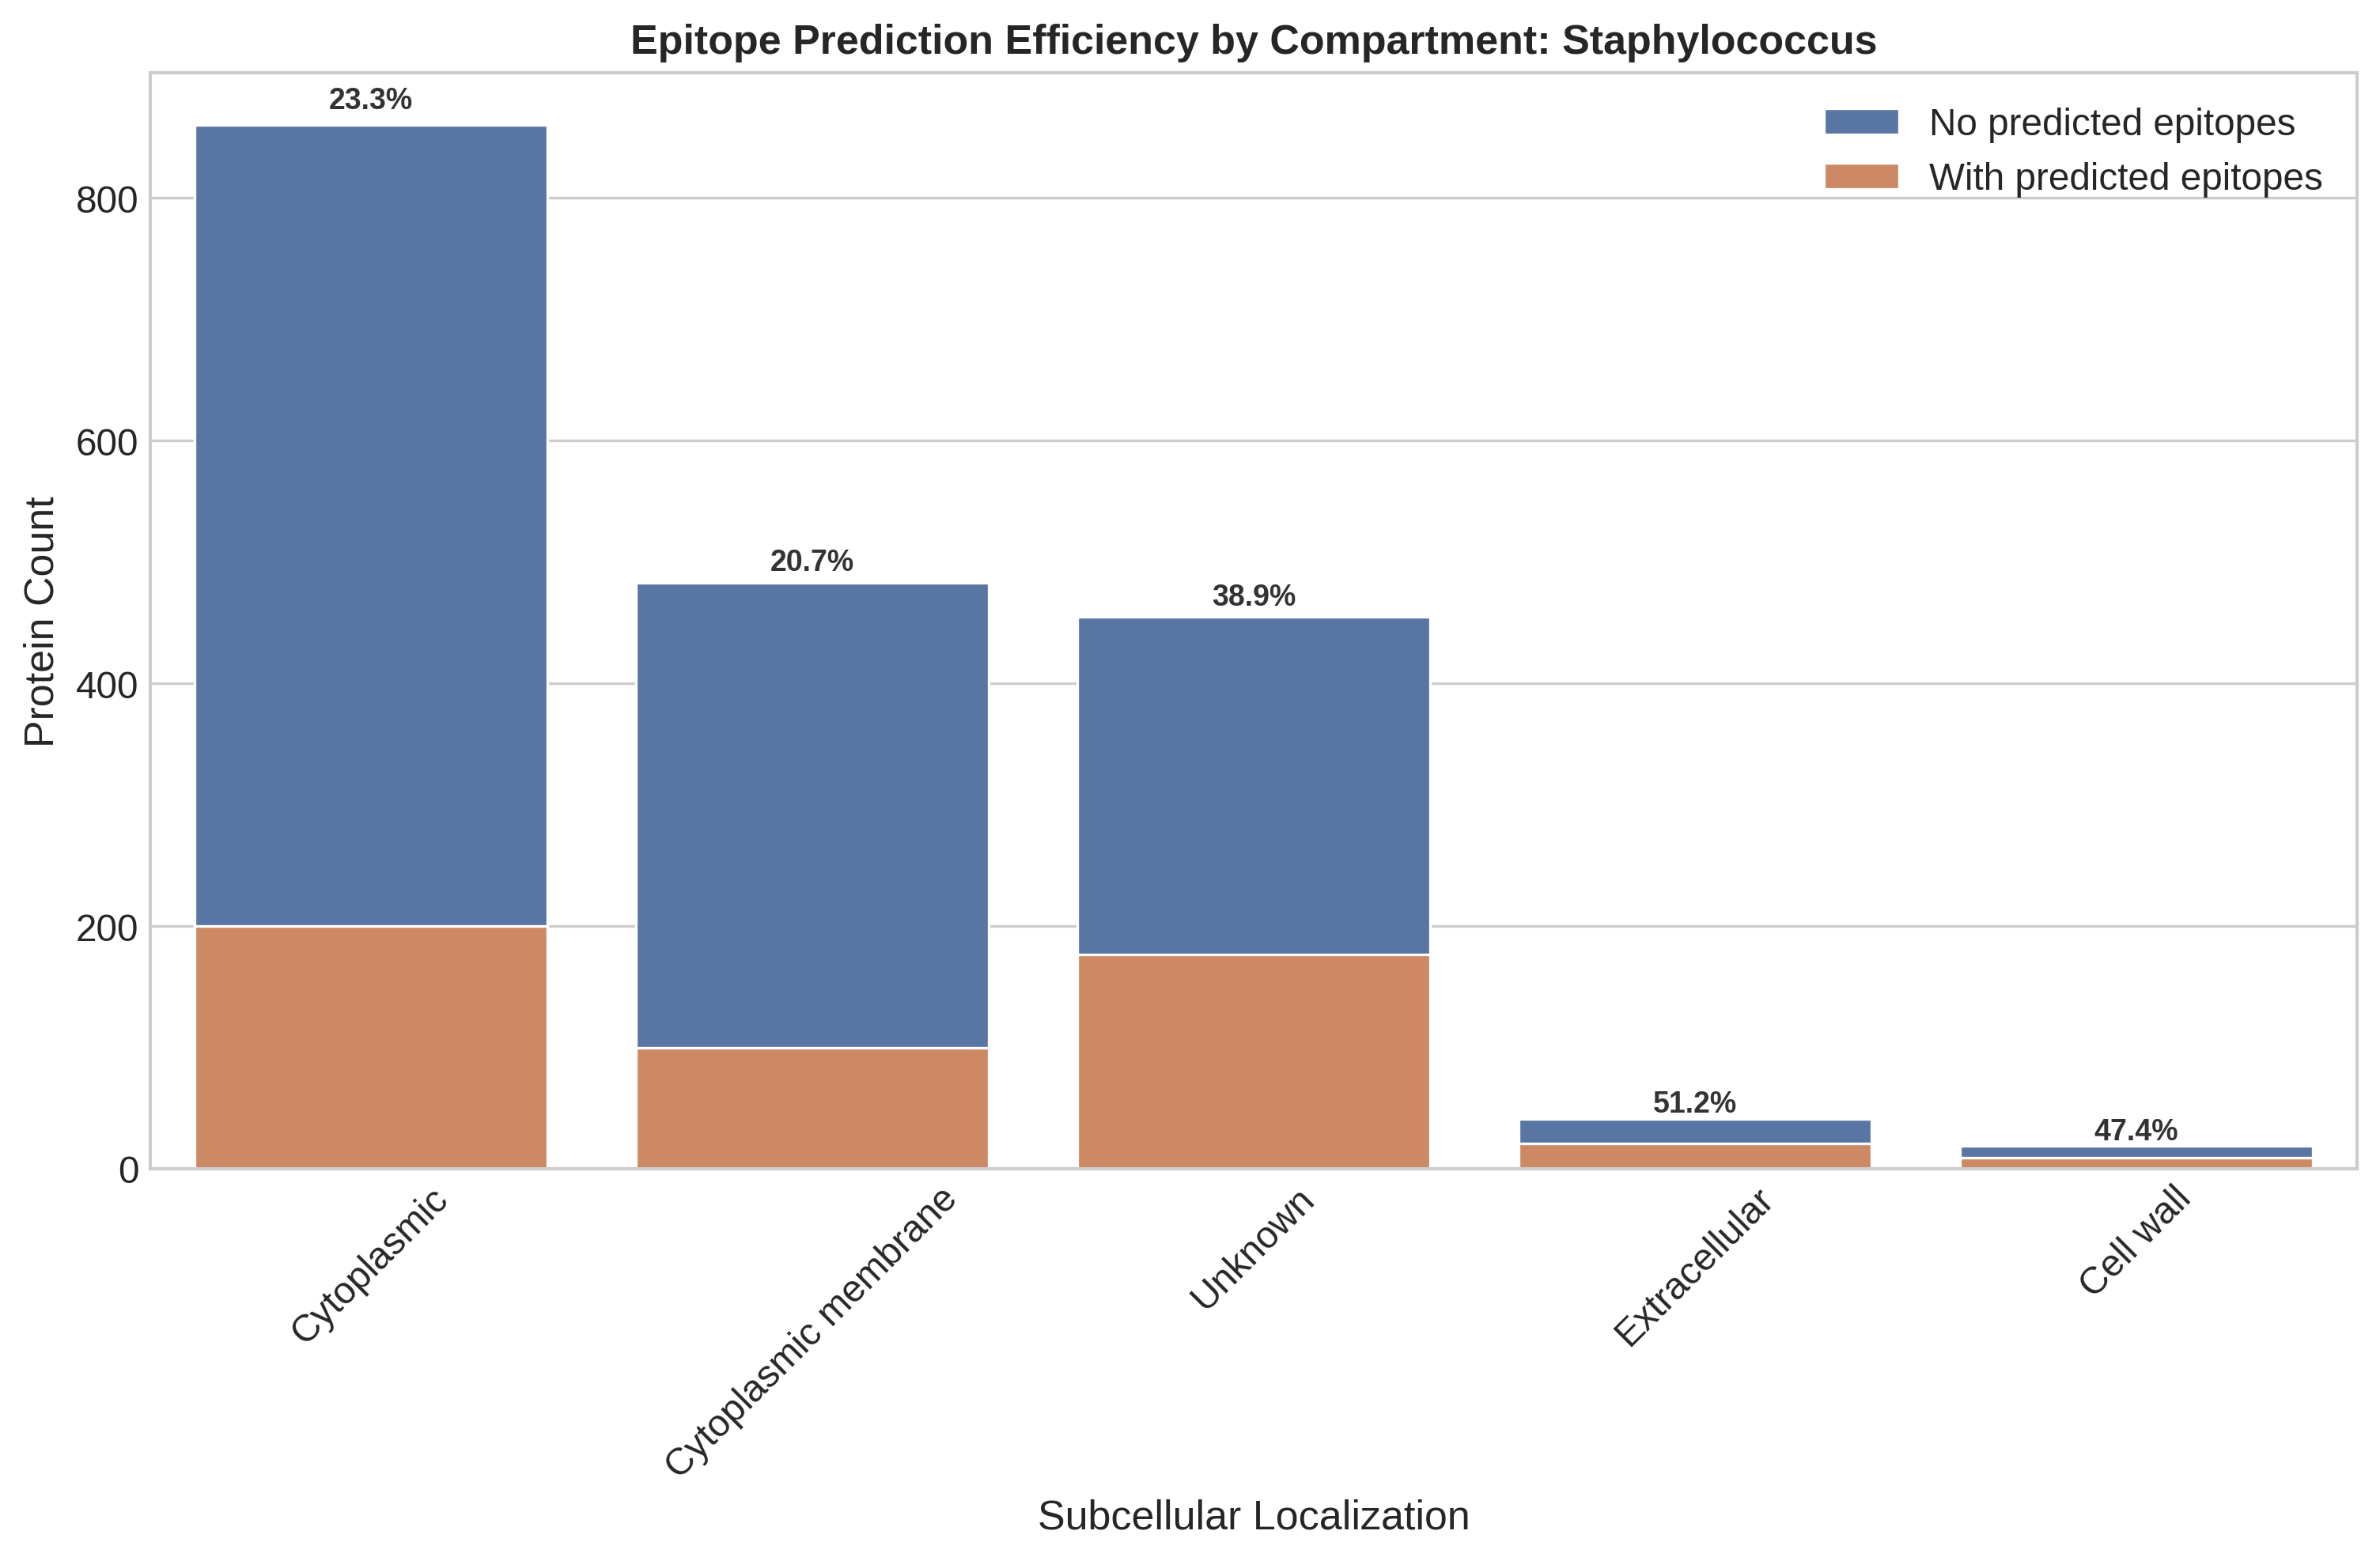

/tmp/ipython-input-1025507590.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sum['Has_Epitope'] = df_sum['Id'].isin(has_epi)


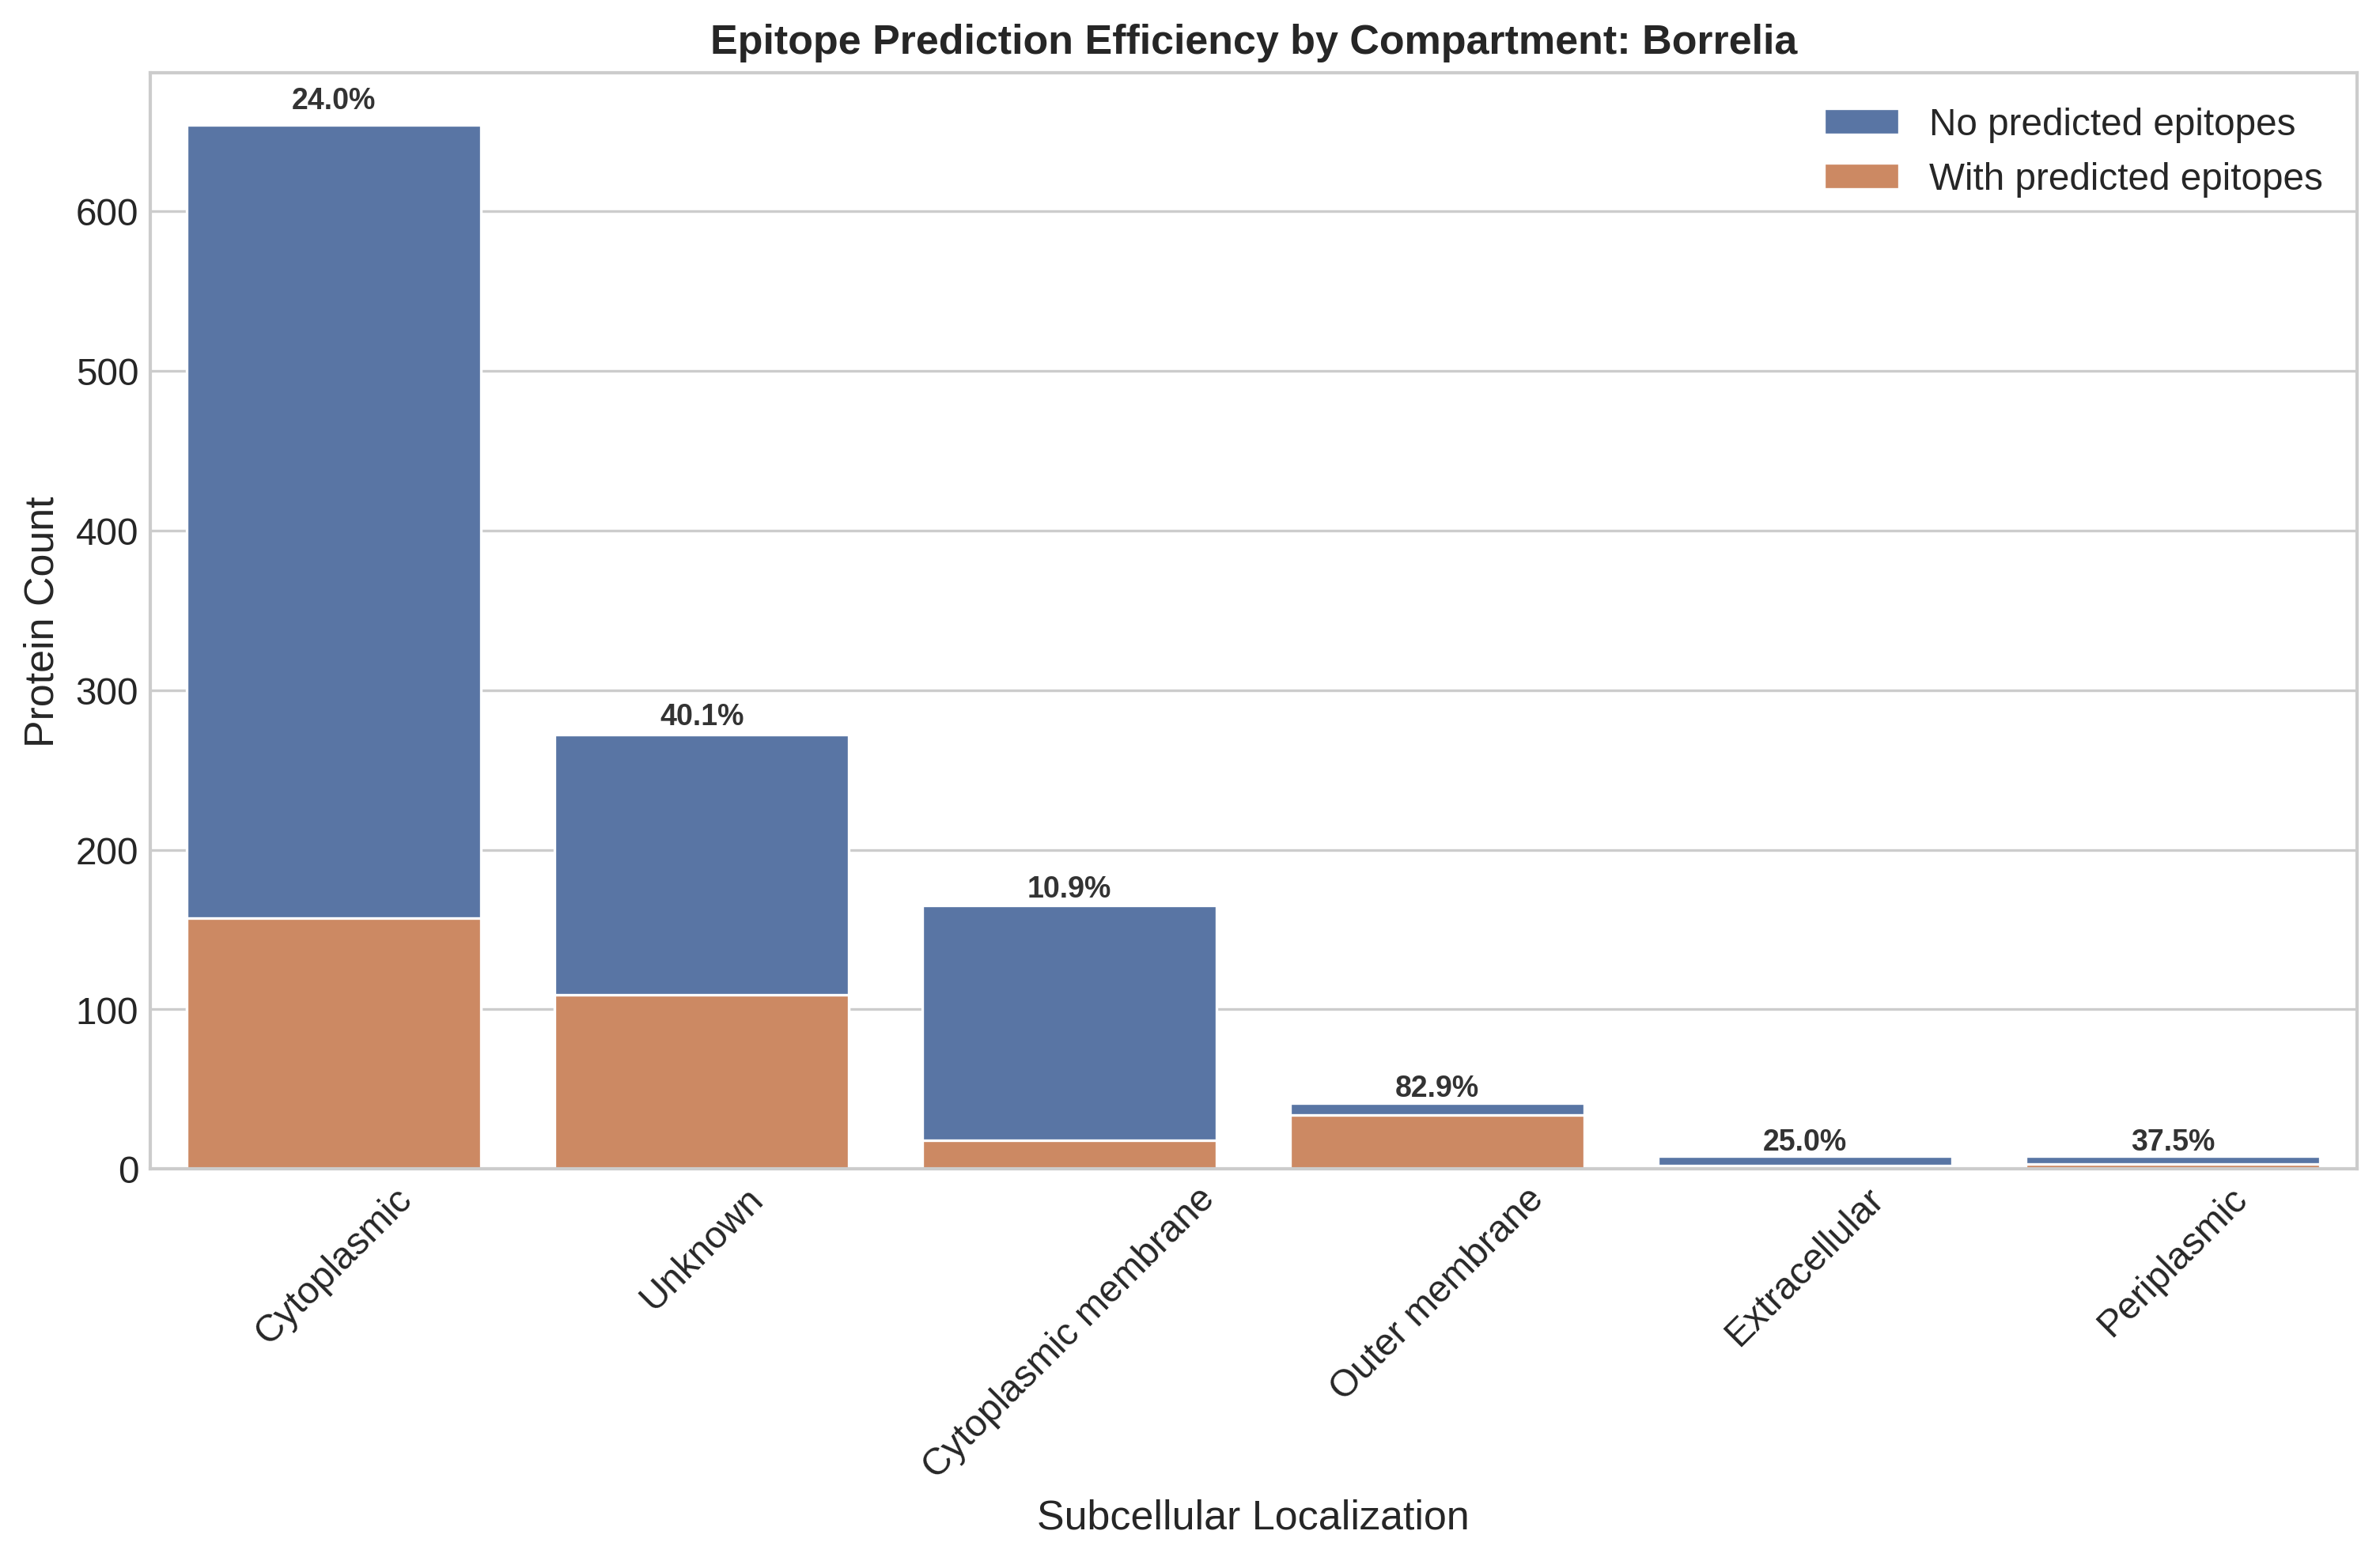

/tmp/ipython-input-1025507590.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sum['Has_Epitope'] = df_sum['Id'].isin(has_epi)


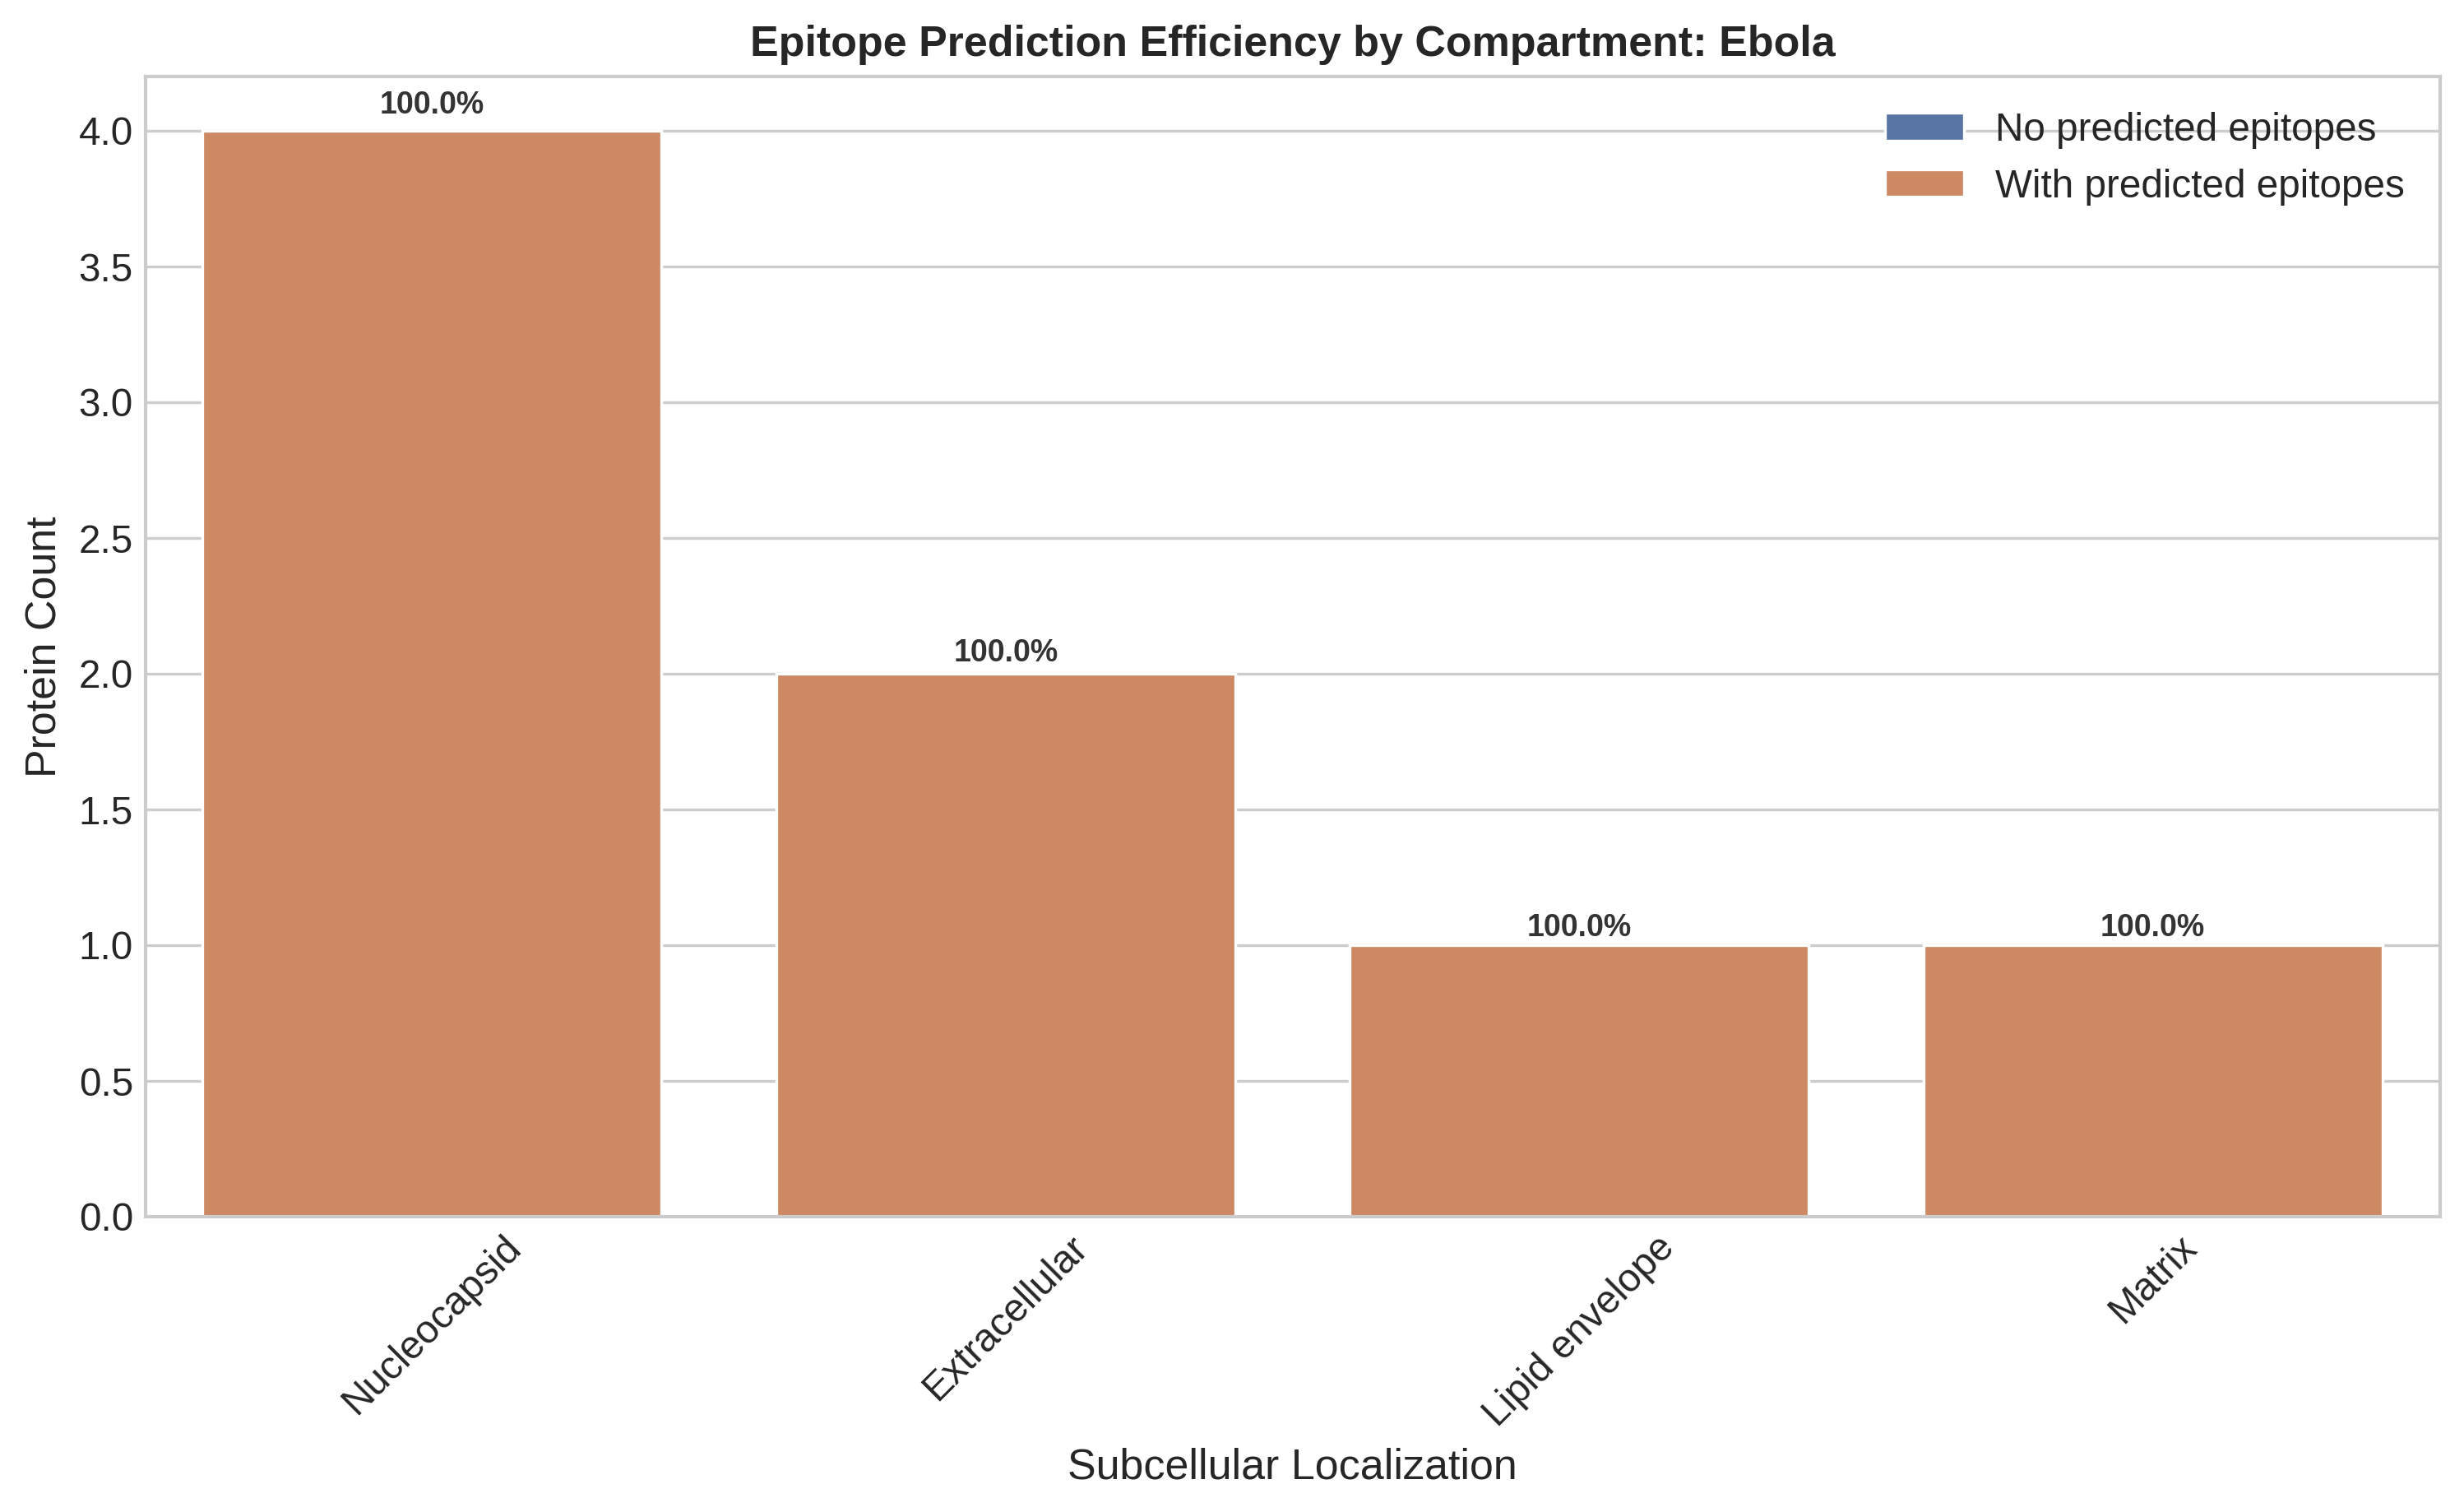

/tmp/ipython-input-1025507590.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sum['Has_Epitope'] = df_sum['Id'].isin(has_epi)


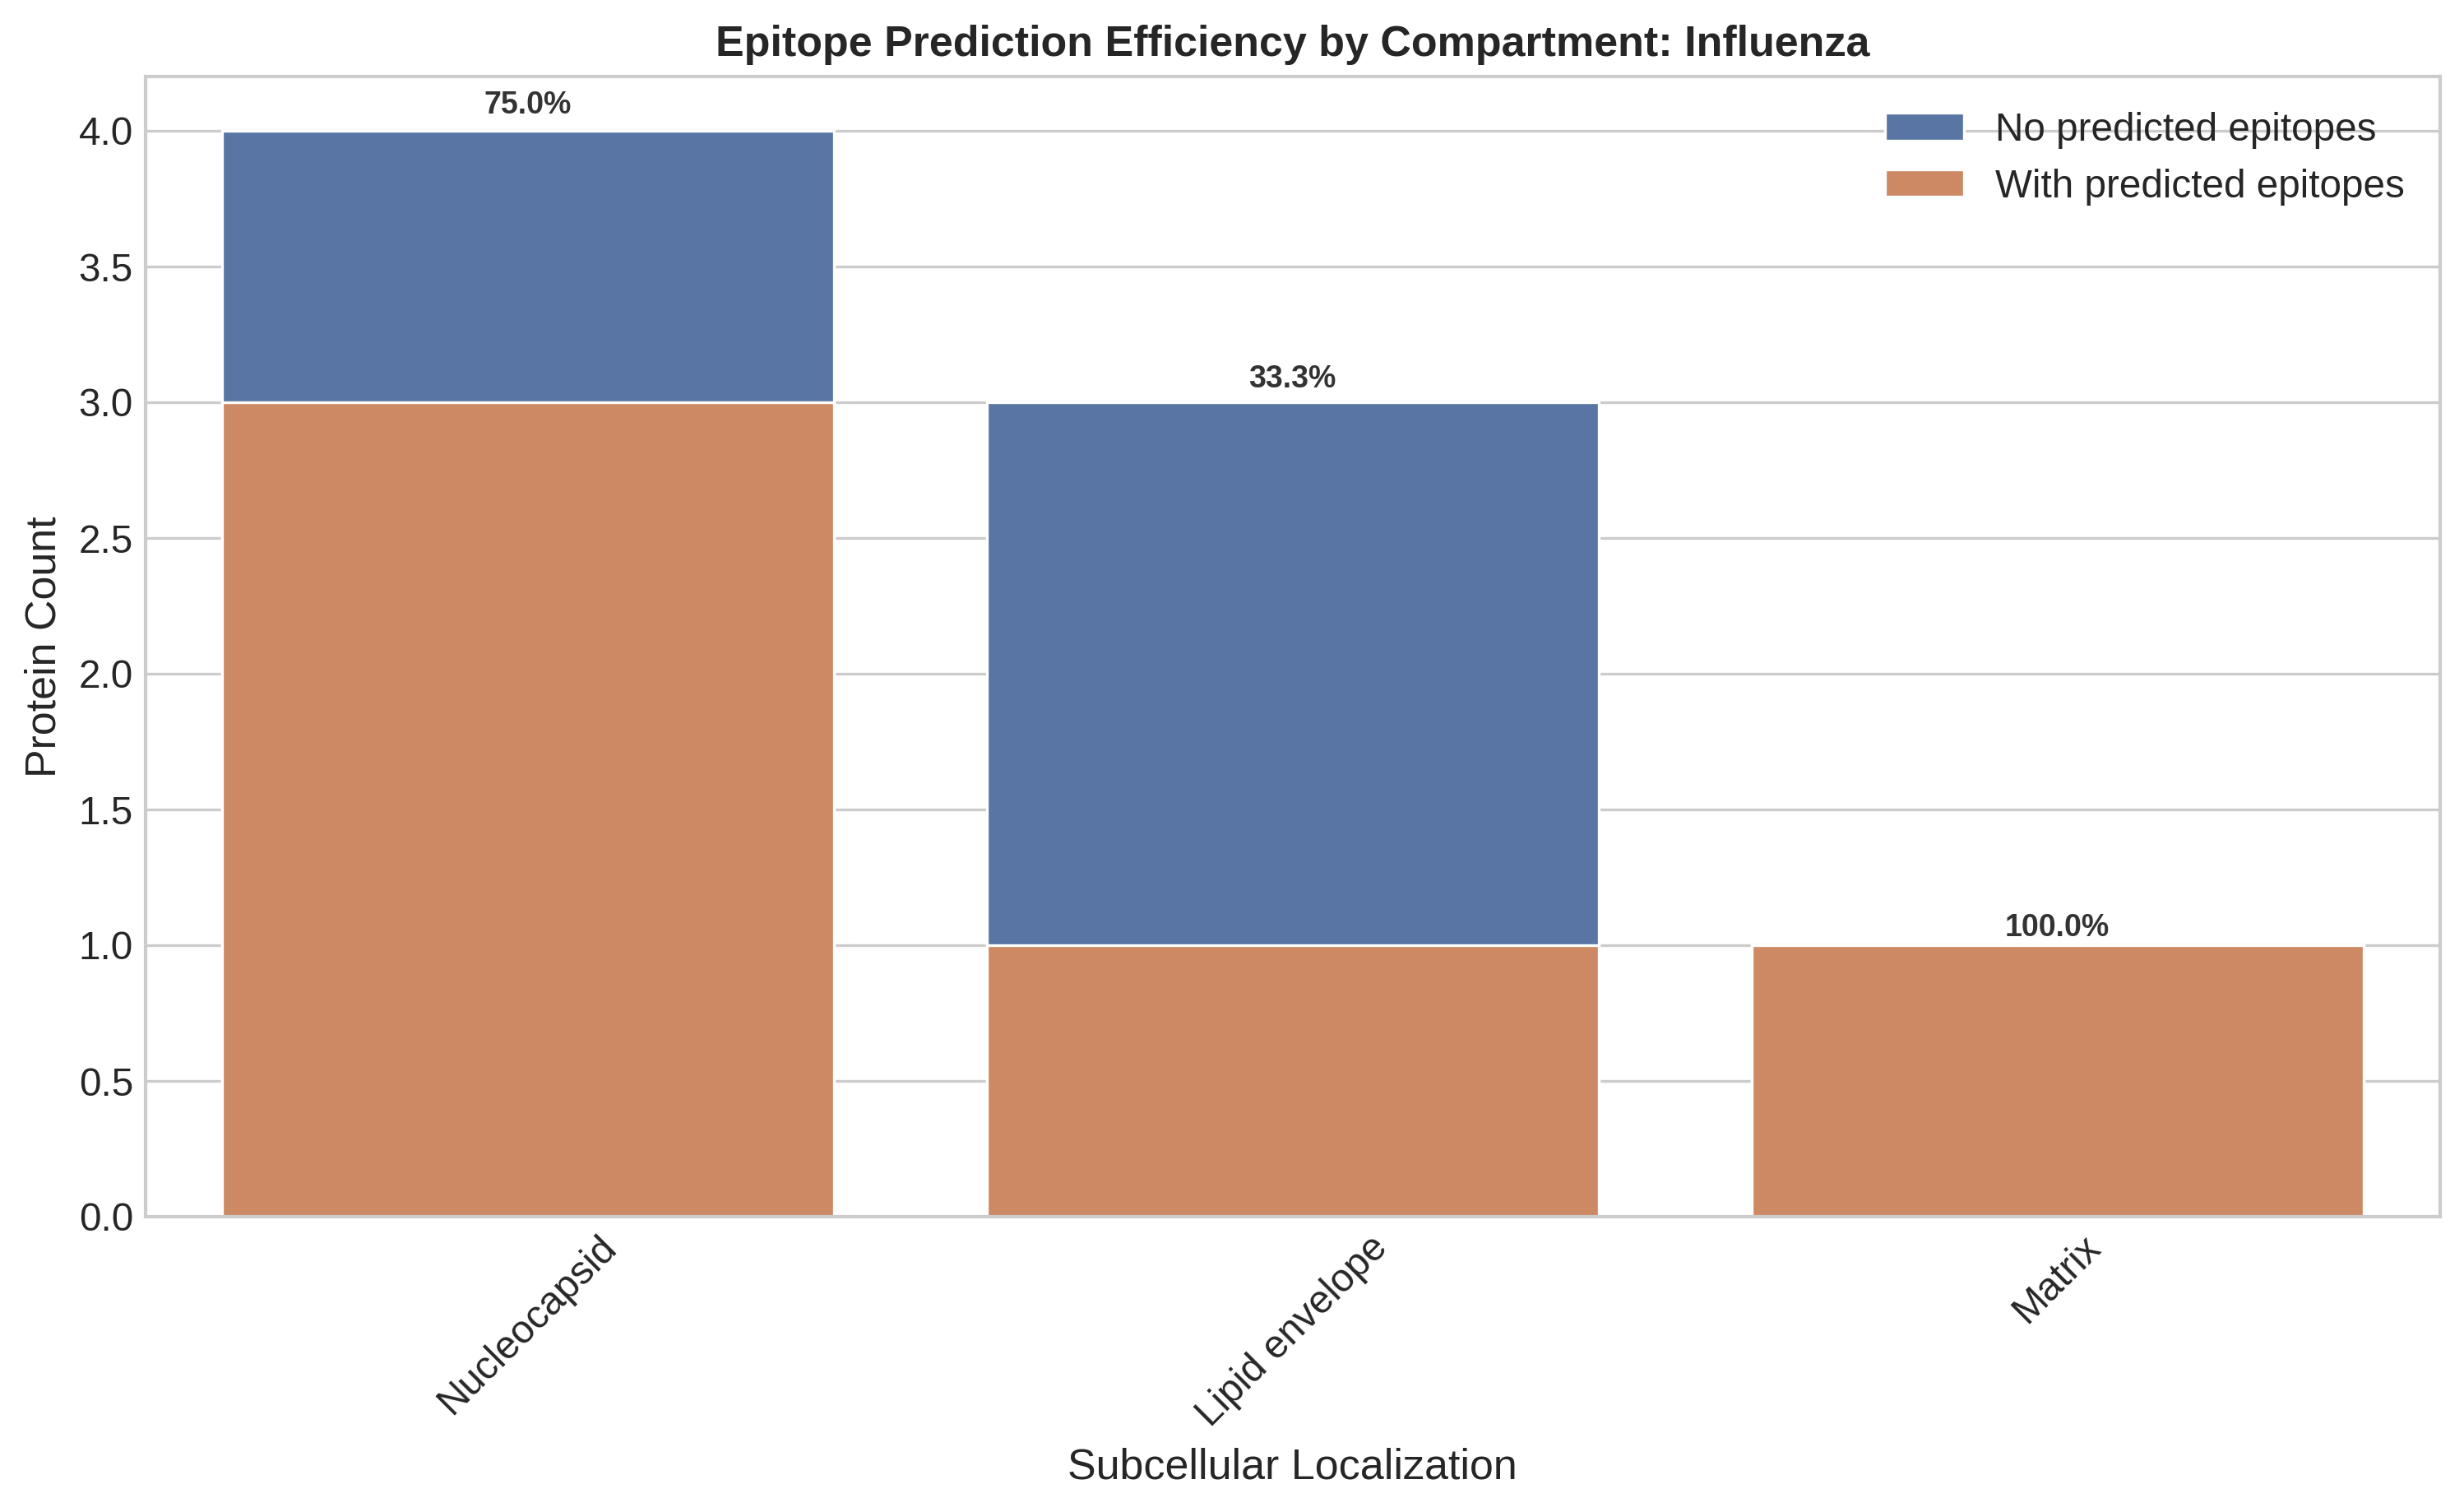

In [ ]:
def plot_complete_subcellular_efficiency(df_sum, df_det, organism_name, allowed_locs, file_name=None):
    """
    Gera um gráfico de barras empilhadas para TODAS as localizações,
    mostrando a porcentagem de proteínas que possuem pelo menos um epítopo.
    """
    # Identificar proteínas com epítopos
    if not df_det.empty:
        has_epi = df_det['Id'].unique()
        df_sum['Has_Epitope'] = df_sum['Id'].isin(has_epi)
    else:
        df_sum['Has_Epitope'] = False

    df_filtered = df_sum[df_sum['Localization'].isin(allowed_locs)].copy()

    counts = df_filtered.groupby('Localization')['Has_Epitope'].value_counts().unstack(fill_value=0)

    if True not in counts.columns: counts[True] = 0
    if False not in counts.columns: counts[False] = 0

    counts['Total'] = counts[True] + counts[False]
    counts['Perc'] = (counts[True] / counts['Total']) * 100
    counts = counts.sort_values(by='Total', ascending=False) # Ordenar pelas mais abundantes

    # Plotagem
    plt.figure(figsize=(12, 6))
    palette = sns.color_palette("deep")

    # Barra de fundo (Proteínas totais - Sem epítopo)
    sns.barplot(x=counts.index, y=counts['Total'], color=palette[0], label='No predicted epitopes')
    # Barra sobreposta (Com epítopo)
    sns.barplot(x=counts.index, y=counts[True], color=palette[1], label='With predicted epitopes')

    for i, (idx, row) in enumerate(counts.iterrows()):
        plt.text(i, row['Total'] + (row['Total']*0.01), f"{row['Perc']:.1f}%",
                 ha='center', va='bottom', fontweight='bold', fontsize=9, color='#333333')

    plt.title(f"Epitope Prediction Efficiency by Compartment: {organism_name}", fontweight='bold')
    plt.ylabel("Protein Count")
    plt.xlabel("Subcellular Localization")
    plt.xticks(rotation=45)
    plt.legend(loc='upper right')

    if file_name:
        plt.savefig(file_name, dpi=600, bbox_inches='tight')
    plt.show()

# Candida
df_candida_sum = df_summary_final[df_summary_final['Organism'] == 'Candida']
df_candida_det = df_detailed_final[df_detailed_final['Organism'] == 'Candida']

plot_complete_subcellular_efficiency(
    df_candida_sum,
    df_candida_det,
    "Candida",
    LOCALIZATIONS_EUCARIOTO,
    "eficiencia_compartimento_candida.png"
)

# Para as Bactérias
#Staphylococcus
df_staph_sum = df_summary_final[df_summary_final['Organism'] == 'Staphylococcus']
df_staph_det = df_detailed_final[df_detailed_final['Organism'] == 'Staphylococcus']

plot_complete_subcellular_efficiency(
    df_staph_sum,
    df_staph_det,
    "Staphylococcus",
    LOCALIZATIONS_PROCARIOTO,
    "eficiencia_compartimento_staph.png"
)
# Borrelia
df_borrelia_sum = df_summary_final[df_summary_final['Organism'] == 'Borrelia']
df_borrelia_det = df_detailed_final[df_detailed_final['Organism'] == 'Borrelia']

plot_complete_subcellular_efficiency(
    df_borrelia_sum,
    df_borrelia_det,
    "Borrelia",
    LOCALIZATIONS_PROCARIOTO,
    "eficiencia_compartimento_borrelia.png"
)

# VIRUS
for v_org in VIRUS:
    df_v_sum = df_summary_final[df_summary_final['Organism'] == v_org]
    df_v_det = df_detailed_final[df_detailed_final['Organism'] == v_org]

    if not df_v_sum.empty:
        plot_complete_subcellular_efficiency(
            df_v_sum,
            df_v_det,
            v_org,
            LOCALIZATIONS_VIRUS,
            f"efficiency_{v_org.lower()}.png"
        )

In [ ]:
from google.colab import files

arquivos_para_baixar = [
    "eficiencia_compartimento_candida.png",
    "eficiencia_compartimento_borrelia.png",
    "eficiencia_compartimento_staph.png",
    "efficiency_ebola.png",
    "efficiency_influenza.png"
]

for arquivo in arquivos_para_baixar:
    try:
        files.download(arquivo)
    except:
        print(f"Erro: O arquivo {arquivo} não foi encontrado. Verifique se o gráfico foi gerado.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>